smoothed rows: 385153 | devices: 461 | crossing events in entire dataset: 82
device-days usable: 328565

--- drift / volatility by voltage level (30-day forward) ---
                 n  drift_per_day  vol_per_day  days_to_2.4_at_this_drift
vbin                                                                     
(2.4, 2.45]   1634      -0.000498     0.012091                  50.173143
(2.45, 2.5]   3634      -0.000415     0.013843                 180.565732
(2.5, 2.55]   5611      -0.000505     0.013496                 247.519385
(2.55, 2.6]   6882      -0.000477     0.015595                 366.680694
(2.6, 2.65]   8886      -0.000536     0.014248                 419.486621
(2.65, 2.7]  12688      -0.000656     0.009743                 419.081983
(2.7, 2.75]  13283      -0.000712     0.010383                 456.605344
(2.75, 2.8]  16144      -0.000571     0.010234                 657.101867
(2.8, 2.85]  21139      -0.000628     0.008474                 676.815977
(2.85, 2.9]  22038  

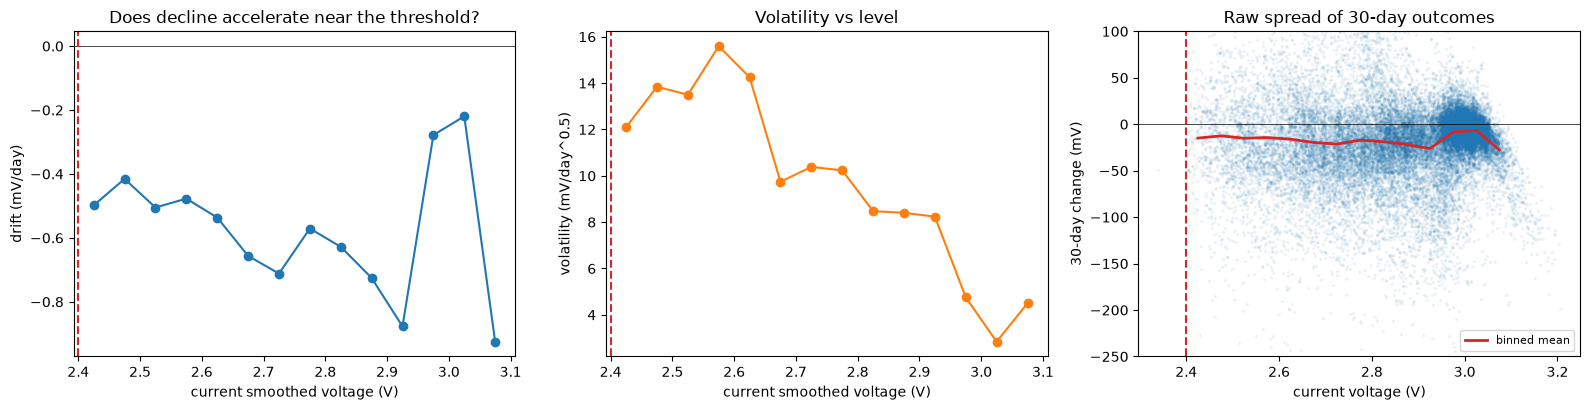

In [11]:
# Step 1: characterise the degradation process
# ============================================================
import warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")

DATA_DIR, CACHE = Path("../data/raw/train"), Path("../data/processed")
V_EOL = 2.4
CACHE = Path("data/processed")
sm = pd.read_parquet(CACHE / "smoothed.parquet")          # built & verified in manual_investigation_step1.ipynb
sm["date"] = pd.to_datetime(sm["date"])
devices = pd.read_csv(DATA_DIR / "devices.csv", parse_dates=["start_time", "end_time"])
eol = pd.read_csv(DATA_DIR / "eol_times.csv")
eol["end_time"] = pd.to_datetime(eol["end_time"])
eol_s = eol.set_index("device_id")["end_time"]
print("smoothed rows:", len(sm), "| devices:", sm.device_id.nunique(),
      "| crossing events in entire dataset:", int(eol_s.notna().sum()))

# --- forward increments on the regular daily grid ---
HS = [7, 30, 60]
parts = []
for dev, g in sm.groupby("device_id", observed=True):
    g = g.sort_values("date").set_index("date")
    v = g["v_smooth"]
    out = pd.DataFrame({"device_id": dev, "date": v.index, "v": v.values,
                        "t_daily": g["t_daily"].values})
    for h in HS:
        out[f"d{h}"] = (v.shift(-h) - v).values      # forward change over h days
    parts.append(out)
P = pd.concat(parts, ignore_index=True).dropna(subset=["v"])

# drop post-EOL segments: after a crossing the cell may have been REPLACED
P = P.merge(eol_s.rename("eol"), left_on="device_id", right_index=True, how="left")
P = P[P.eol.isna() | (P.date <= P.eol)]
print("device-days usable:", len(P))

# --- drift and volatility as a function of voltage level ---
P["vbin"] = pd.cut(P.v, np.arange(2.35, 3.15, 0.05))
g30 = P.dropna(subset=["d30"]).groupby("vbin", observed=True)["d30"]
stats = pd.DataFrame({"n": g30.size(), "drift_per_day": g30.mean()/30,
                      "vol_per_day": g30.std()/np.sqrt(30)})
stats["days_to_2.4_at_this_drift"] = [
    (m - V_EOL) / -dr if dr < 0 else np.inf
    for m, dr in zip([i.mid for i in stats.index], stats.drift_per_day)]
print("\n--- drift / volatility by voltage level (30-day forward) ---")
print(stats[stats.n > 200].round(6).to_string())

# --- between- vs within-device variance in drift ---
dev_drift = (P.dropna(subset=["d30"]).groupby("device_id")["d30"].agg(["mean","std","size"]))
dev_drift = dev_drift[dev_drift["size"] > 100]
print(f"\nper-device mean 30d drift: sd across devices = {dev_drift['mean'].std():.5f}")
print(f"typical within-device sd of 30d drift        = {dev_drift['std'].median():.5f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
s = stats[stats.n > 200]; mids = [i.mid for i in s.index]
ax[0].plot(mids, s.drift_per_day * 1000, marker="o", color="tab:blue")
ax[0].axhline(0, color="k", lw=.5); ax[0].axvline(V_EOL, color="tab:red", ls="--")
ax[0].set_xlabel("current smoothed voltage (V)"); ax[0].set_ylabel("drift (mV/day)")
ax[0].set_title("Does decline accelerate near the threshold?")

ax[1].plot(mids, s.vol_per_day * 1000, marker="o", color="tab:orange")
ax[1].axvline(V_EOL, color="tab:red", ls="--")
ax[1].set_xlabel("current smoothed voltage (V)"); ax[1].set_ylabel("volatility (mV/day^0.5)")
ax[1].set_title("Volatility vs level")

samp = P.dropna(subset=["d30"]).sample(40000, random_state=0)
ax[2].scatter(samp.v, samp.d30 * 1000, s=2, alpha=.06)
ax[2].plot(mids, s.drift_per_day * 30 * 1000, color="tab:red", lw=2, label="binned mean")
ax[2].axvline(V_EOL, color="tab:red", ls="--"); ax[2].axhline(0, color="k", lw=.5)
ax[2].set_ylim(-250, 100)
ax[2].set_xlabel("current voltage (V)"); ax[2].set_ylabel("30-day change (mV)")
ax[2].set_title("Raw spread of 30-day outcomes"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

rows: 303448

A. shortest observed lifetime to crossing: 367 days | 1st pct: 378 | 5th pct: 506
   devices crossing before 400 days: 2 / 82

B. temperature sensitivity across 455 devices
   median b = 0.00646 V/degC   positive in 97.4% of devices
   median R^2 of dv on dt = 0.229
   median sd(dv30)          = 0.03482
   median sd after removing = 0.02929   -> volatility reduction 12.2%
   implied 42d sd: 0.0412 V  ->  0.0347 V

C. temperature sensitivity by voltage level
                  n        b
vbin                        
(2.4, 2.5]   5275.0  0.01646
(2.5, 2.6]  12486.0  0.01287
(2.6, 2.7]  21574.0  0.01287
(2.7, 2.8]  29427.0  0.01145
(2.8, 2.9]  43177.0  0.00782
(2.9, 3.0]  96041.0  0.00586
(3.0, 3.1]  93847.0  0.00394

D. mean 30-day voltage & temperature change by calendar month
       dv_mean  dt_mean      n
month                         
1      -0.0222  -0.0128  20959
2      -0.0062   1.2140  21865
3      -0.0028   1.1575  27068
4       0.0012   1.4997  28475
5      -0.0100

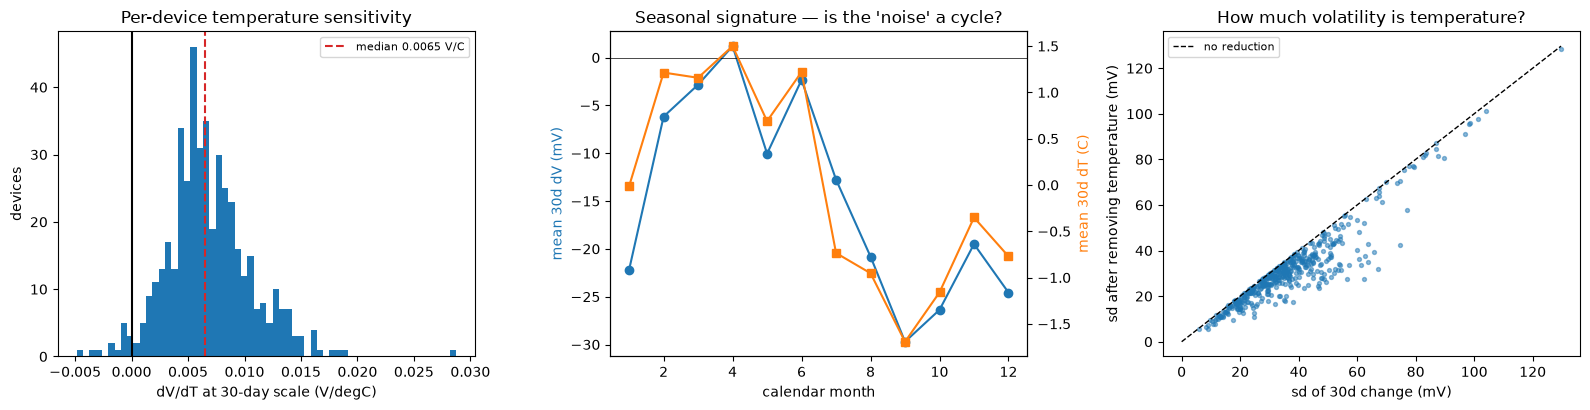

In [12]:
# Step 2: is the volatility predictable?
# Expects: sm, eol_s, devices, np, pd, plt
H = 30
parts = []
for dev, g in sm.groupby("device_id", observed=True):
    g = g.sort_values("date").set_index("date")
    v = g["v_smooth"]
    t = g["t_daily"].rolling(7, min_periods=3).median()      # match v's smoothing
    parts.append(pd.DataFrame({
        "device_id": dev, "date": v.index, "v": v.values, "t": t.values,
        "dv": (v.shift(-H) - v).values, "dt": (t.shift(-H) - t).values}))
Q = pd.concat(parts, ignore_index=True).merge(
        eol_s.rename("eol"), left_on="device_id", right_index=True, how="left")
Q = Q[Q.eol.isna() | (Q.date <= Q.eol)].dropna(subset=["dv", "dt", "v", "t"])
print("rows:", len(Q))

# --- A. KM floor: does the 380-day rule hold with zero exceptions? ---
start = devices.set_index("device_id")["start_time"].dt.tz_localize(None).dt.normalize()
life = (eol_s.dropna() - start.reindex(eol_s.dropna().index)).dt.days
print(f"\nA. shortest observed lifetime to crossing: {life.min()} days "
      f"| 1st pct: {life.quantile(0.01):.0f} | 5th pct: {life.quantile(0.05):.0f}")
print(f"   devices crossing before 400 days: {int((life < 400).sum())} / {len(life)}")

# --- B. per-device temperature sensitivity at the 30-day scale ---
rows = []
for dev, g in Q.groupby("device_id"):
    if len(g) < 100 or g.dt.std() < 1e-6: continue
    b = np.cov(g.dt, g.dv)[0, 1] / np.var(g.dt)
    r2 = np.corrcoef(g.dt, g.dv)[0, 1] ** 2
    rows.append({"device_id": dev, "b_V_per_C": b, "r2": r2,
                 "sd_dv": g.dv.std(), "sd_resid": (g.dv - b * g.dt).std()})
B = pd.DataFrame(rows)
print(f"\nB. temperature sensitivity across {len(B)} devices")
print(f"   median b = {B.b_V_per_C.median():.5f} V/degC   "
      f"positive in {(B.b_V_per_C > 0).mean():.1%} of devices")
print(f"   median R^2 of dv on dt = {B.r2.median():.3f}")
print(f"   median sd(dv30)          = {B.sd_dv.median():.5f}")
print(f"   median sd after removing = {B.sd_resid.median():.5f}"
      f"   -> volatility reduction {1 - (B.sd_resid/B.sd_dv).median():.1%}")
print(f"   implied 42d sd: {B.sd_dv.median()/np.sqrt(H)*np.sqrt(42):.4f} V"
      f"  ->  {B.sd_resid.median()/np.sqrt(H)*np.sqrt(42):.4f} V")

# --- C. does sensitivity grow as the battery depletes? ---
Q["vbin"] = pd.cut(Q.v, np.arange(2.4, 3.1, 0.1))
sens = Q.groupby("vbin", observed=True).apply(
    lambda g: pd.Series({"n": len(g),
                         "b": np.cov(g.dt, g.dv)[0,1]/np.var(g.dt) if g.dt.std()>1e-6 else np.nan}))
print("\nC. temperature sensitivity by voltage level")
print(sens[sens.n > 500].round(5).to_string())

# --- D. seasonal signature ---
Q["month"] = Q.date.dt.month
seas = Q.groupby("month").agg(dv_mean=("dv","mean"), dt_mean=("dt","mean"), n=("dv","size"))
print("\nD. mean 30-day voltage & temperature change by calendar month")
print(seas.round(4).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(B.b_V_per_C, bins=60, color="tab:blue")
ax[0].axvline(0, color="k"); ax[0].axvline(B.b_V_per_C.median(), color="tab:red", ls="--",
    label=f"median {B.b_V_per_C.median():.4f} V/C")
ax[0].set_xlabel("dV/dT at 30-day scale (V/degC)"); ax[0].set_ylabel("devices")
ax[0].set_title("Per-device temperature sensitivity"); ax[0].legend(fontsize=8)

ax[1].plot(seas.index, seas.dv_mean*1000, marker="o", color="tab:blue", label="dV (mV)")
a1 = ax[1].twinx(); a1.plot(seas.index, seas.dt_mean, marker="s", color="tab:orange", label="dT (C)")
ax[1].axhline(0, color="k", lw=.5); ax[1].set_xlabel("calendar month")
ax[1].set_ylabel("mean 30d dV (mV)", color="tab:blue"); a1.set_ylabel("mean 30d dT (C)", color="tab:orange")
ax[1].set_title("Seasonal signature — is the 'noise' a cycle?")

ax[2].scatter(B.sd_dv*1000, B.sd_resid*1000, s=8, alpha=.5)
lim = [0, B.sd_dv.max()*1000]
ax[2].plot(lim, lim, "k--", lw=1, label="no reduction")
ax[2].set_xlabel("sd of 30d change (mV)"); ax[2].set_ylabel("sd after removing temperature (mV)")
ax[2].set_title("How much volatility is temperature?"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

--- A. cohort hazard, exposure corrected (cohorts n>=8) ---
           n  events  dev_years  naive_rate  haz_per_yr     lo     hi
cohort                                                               
2023-01   30       7     94.133       0.233       0.074  0.035  0.156
2023-03   14       4     44.014       0.286       0.091  0.034  0.242
2023-07   34       9     96.367       0.265       0.093  0.049  0.179
2023-08    8       0     22.875       0.000       0.000  0.000  0.000
2023-09   24      15     55.118       0.625       0.272  0.164  0.451
2023-10   23       7     60.873       0.304       0.115  0.055  0.241
2023-11   11       3     27.934       0.273       0.107  0.035  0.333
2024-01   44       9    101.232       0.205       0.089  0.046  0.171
2024-02   18       3     43.715       0.167       0.069  0.022  0.213
2024-03   10       1     19.209       0.100       0.052  0.007  0.370
2024-04  113       4    240.901       0.035       0.017  0.006  0.044
2024-06   16       1     32.94

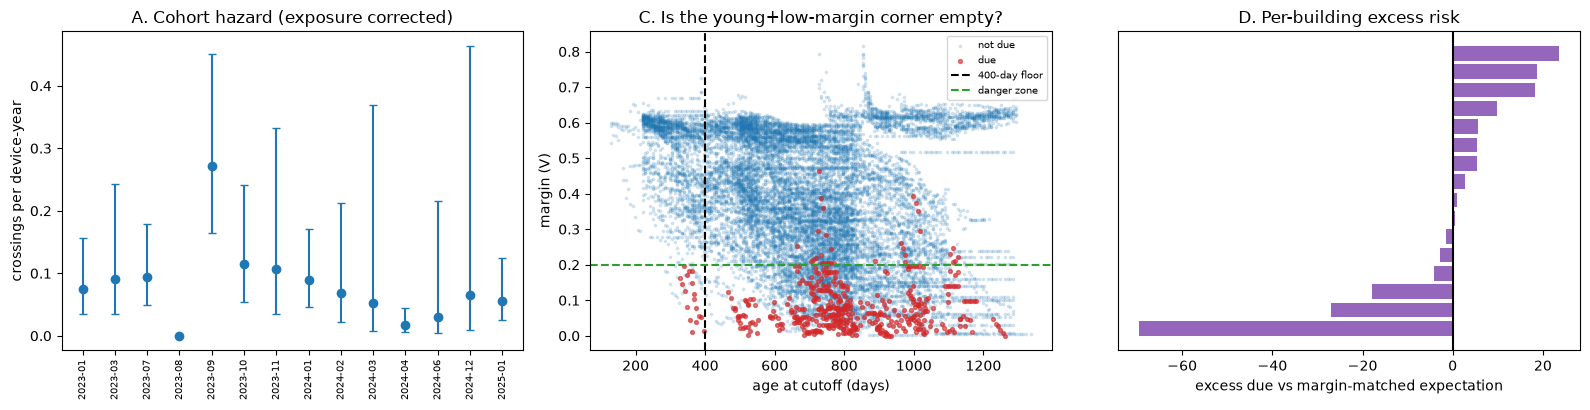

In [13]:
# Step 3 (cheap): does age or building add anything beyond voltage?
# Expects: sm, eol_s, devices, feat (from cutoff_features.parquet), np, pd, plt
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
feat = pd.read_parquet(Path("data/processed") / "cutoff_features.parquet")

start   = devices.set_index("device_id")["start_time"].dt.tz_localize(None).dt.normalize()
last_ob = sm.dropna(subset=["v_smooth"]).groupby("device_id")["date"].max()
bldg    = devices.set_index("device_id")["building_id"]

surv = pd.DataFrame({"start": start, "eol": eol_s.reindex(start.index),
                     "last_obs": last_ob.reindex(start.index), "building": bldg})
surv["event"]     = surv.eol.notna()
surv["exit"]      = surv.eol.fillna(surv.last_obs)
surv["risk_days"] = (surv.exit - surv.start).dt.days
surv["cohort"]    = surv.start.dt.to_period("M").astype(str)

# --- A. exposure-corrected hazard by deployment cohort ---
A = surv.groupby("cohort").agg(n=("event","size"), events=("event","sum"),
                               dev_years=("risk_days", lambda s: s.sum()/365.25))
A = A[A.n >= 8]
A["naive_rate"]  = A.events / A.n
A["haz_per_yr"]  = A.events / A.dev_years
A["lo"] = A.haz_per_yr * np.exp(-1.96/np.sqrt(A.events.clip(lower=1)))
A["hi"] = A.haz_per_yr * np.exp( 1.96/np.sqrt(A.events.clip(lower=1)))
print("--- A. cohort hazard, exposure corrected (cohorts n>=8) ---")
print(A.round(3).to_string())

# --- B. is deploy cohort separable from building? ---
print("\n--- B. cohort vs building nesting ---")
print("buildings per cohort  :", surv.groupby("cohort")["building"].nunique().describe()[["mean","50%","max"]].round(2).to_dict())
print("cohorts per building  :", surv.groupby("building")["cohort"].nunique().describe()[["mean","50%","max"]].round(2).to_dict())
single = surv.groupby("building")["cohort"].nunique().eq(1)
print(f"buildings with ONE cohort: {single.sum()} / {len(single)} "
      f"({surv.building.isin(single[single].index).mean():.1%} of devices)")

# --- C. THE decisive age test ---
print("\n--- C. does age survive conditioning on margin? ---")
ct = pd.crosstab(feat.age_days < 400, feat.margin < 0.20)
ct.index.name, ct.columns.name = "age<400", "margin<0.20"
print(ct)
young_danger = feat[(feat.age_days < 400) & (feat.margin < 0.20)]
print(f"rows young AND near threshold: {len(young_danger)}  of which due: {int(young_danger.due.sum())}")
print(f"a 400-day veto would remove {len(young_danger)} candidate rows "
      f"and lose {int(young_danger.due.sum())} true positives")

from sklearn.metrics import roc_auc_score
feat["mbin"] = pd.qcut(feat.margin, 10, duplicates="drop")
print("\nAUC of age WITHIN each margin decile (0.5 = adds nothing):")
for b, g in feat.groupby("mbin", observed=True):
    if g.due.nunique() == 2:
        print(f"  margin {str(b):24s} n={len(g):5d} due={int(g.due.sum()):4d} "
              f"AUC(age)={roc_auc_score(g.due, g.age_days):.3f}")

# --- D. does BUILDING survive conditioning on margin? ---
print("\n--- D. building effect after conditioning on margin ---")
dz = feat[feat.margin < 0.20].copy()
exp_rate = dz.groupby("mbin", observed=True)["due"].transform("mean")
dz["excess"] = dz.due.astype(float) - exp_rate
bstat = dz.groupby("building").agg(n=("due","size"), due=("due","sum"),
                                   expected=("due", lambda s: 0)).join(
        dz.groupby("building")["excess"].sum().rename("excess_due"))
bstat["expected"] = bstat.due - bstat.excess_due
bstat = bstat[bstat.n >= 50].sort_values("excess_due")
print(bstat.round(1).to_string())
print(f"\nsd of per-building excess due (should be ~0 if building adds nothing): "
      f"{bstat.excess_due.std():.1f} over {len(bstat)} buildings")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].errorbar(range(len(A)), A.haz_per_yr, yerr=[A.haz_per_yr-A.lo, A.hi-A.haz_per_yr],
               fmt="o", capsize=3)
ax[0].set_xticks(range(len(A))); ax[0].set_xticklabels(A.index, rotation=90, fontsize=7)
ax[0].set_ylabel("crossings per device-year"); ax[0].set_title("A. Cohort hazard (exposure corrected)")

s = feat.sample(min(15000, len(feat)), random_state=0)
ax[1].scatter(s.age_days, s.margin, s=3, alpha=.15, label="not due")
dsel = feat[feat.due]
ax[1].scatter(dsel.age_days, dsel.margin, s=8, alpha=.6, color="tab:red", label="due")
ax[1].axvline(400, color="k", ls="--", label="400-day floor")
ax[1].axhline(0.20, color="tab:green", ls="--", label="danger zone")
ax[1].set_xlabel("age at cutoff (days)"); ax[1].set_ylabel("margin (V)")
ax[1].set_title("C. Is the young+low-margin corner empty?"); ax[1].legend(fontsize=7)

ax[2].barh(range(len(bstat)), bstat.excess_due, color="tab:purple")
ax[2].axvline(0, color="k"); ax[2].set_yticks([])
ax[2].set_xlabel("excess due vs margin-matched expectation")
ax[2].set_title("D. Per-building excess risk")
plt.tight_layout(); plt.show()

young+due rows: 18 | distinct devices: 3
                n_scen  min_age  max_age
device_id                               
d_30e86d81563a       6      340      375
d_c6e9d12f54f4       6      327      362
d_cbf684280da2       6      361      396

merged: (19890, 30) | dvdt available: 0.981

--- AUC within margin sextiles, danger zone (n=3982, due=423) ---
feature            1       2       3       4       5       6   pooled
t_mean_90      0.536   0.587   0.754   0.705   0.698   0.565   0.617
t_sd_90        0.564   0.683   0.615   0.644   0.693   0.552   0.578
t_mean_365     0.503   0.427   0.559   0.534   0.459   0.447   0.496
t_sd_365       0.502   0.592   0.524   0.685   0.589   0.578   0.511
dvdt           0.562   0.499   0.567   0.780   0.679   0.533   0.566

--- building excess vs building climate ---
                   n  excess  t_mean   t_sd   dvdt  excess_per_100
building                                                          
b_55038c6689a0   284 -23.610  19.973  2.629  0.0

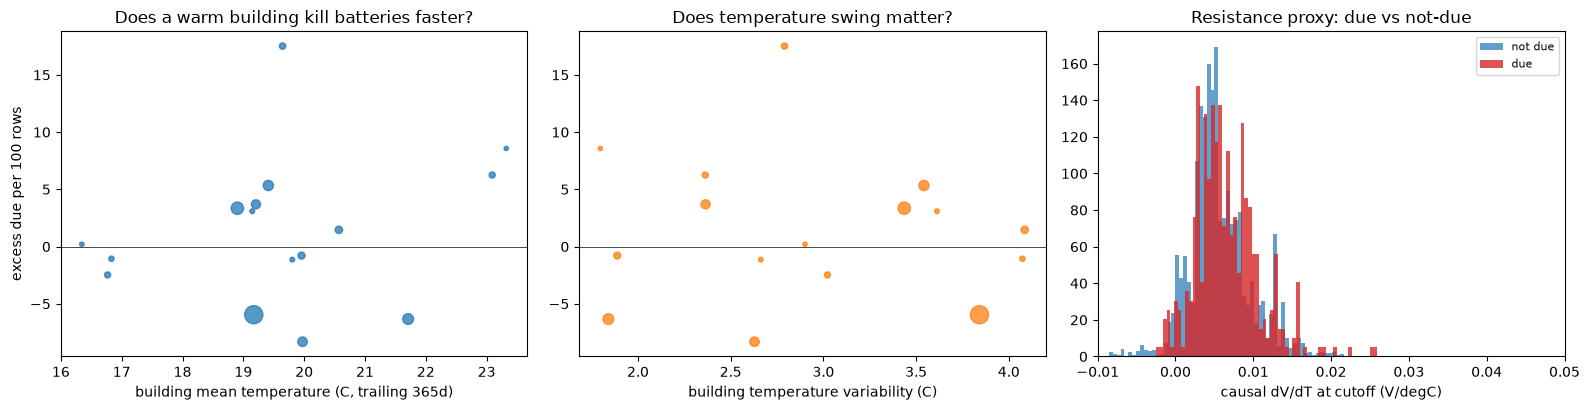

In [14]:
# Step 4: can transferable physics replace building identity?
# Expects: sm, feat, devices, eol_s, np, pd, plt
from sklearn.metrics import roc_auc_score

# --- 0. how many DEVICES are behind those 18 young+due rows? ---
yd = feat[(feat.age_days < 400) & (feat.margin < 0.20) & feat.due]
print("young+due rows:", len(yd), "| distinct devices:", yd.device_id.nunique())
print(yd.groupby("device_id").agg(n_scen=("scenario","size"),
                                  min_age=("age_days","min"), max_age=("age_days","max")).to_string())

# --- 1. causal temperature features at each cutoff ---
S = {}
for dev, g in sm.groupby("device_id", observed=True):
    g = g.sort_values("date")
    t = pd.to_datetime(g["date"]).values.astype("datetime64[D]").astype(int)
    S[dev] = (t, g["t_daily"].values, g["v_smooth"].values)

rows = []
for (scen, cut), grp in feat.groupby(["scenario", "cutoff"]):
    ci = np.datetime64(pd.Timestamp(cut), "D").astype(int)
    for dev in grp.device_id:
        t, tv, vv = S[dev]
        k = np.searchsorted(t, ci, side="right")            # strict truncation
        if k < 30: 
            rows.append({"scenario": scen, "device_id": dev}); continue
        w90  = tv[max(0, k-90):k];  w365 = tv[max(0, k-365):k]
        # causal dV/dT: 30-day paired changes, all within the pre-cutoff window
        j = max(0, k-400)
        vs, ts_ = vv[j:k], tv[j:k]
        dv = vs[30:] - vs[:-30] if len(vs) > 40 else np.array([])
        dt = ts_[30:] - ts_[:-30] if len(ts_) > 40 else np.array([])
        ok = np.isfinite(dv) & np.isfinite(dt)
        b = (np.cov(dt[ok], dv[ok])[0,1] / np.var(dt[ok])
             if ok.sum() > 30 and np.var(dt[ok]) > 1e-6 else np.nan)
        rows.append({"scenario": scen, "device_id": dev,
                     "t_mean_90":  np.nanmean(w90),  "t_sd_90": np.nanstd(w90),
                     "t_mean_365": np.nanmean(w365), "t_sd_365": np.nanstd(w365),
                     "dvdt": b})
T = pd.DataFrame(rows)
F = feat.merge(T, on=["scenario", "device_id"], how="left")
print("\nmerged:", F.shape, "| dvdt available:", F.dvdt.notna().mean().round(3))

# --- 2. do temperature features add anything BEYOND margin? ---
dz = F[(F.margin < 0.20)].copy()
dz["mbin"] = pd.qcut(dz.margin, 6, duplicates="drop")
cand = ["t_mean_90", "t_sd_90", "t_mean_365", "t_sd_365", "dvdt"]
print(f"\n--- AUC within margin sextiles, danger zone (n={len(dz)}, due={int(dz.due.sum())}) ---")
print(f"{'feature':12s} " + " ".join(f"{str(i+1):>7s}" for i in range(6)) + "   pooled")
for c in cand:
    aucs = []
    for b_, g in dz.groupby("mbin", observed=True):
        g = g.dropna(subset=[c])
        aucs.append(roc_auc_score(g.due, g[c]) if g.due.nunique() == 2 and len(g) > 50 else np.nan)
    gg = dz.dropna(subset=[c])
    pooled = roc_auc_score(gg.due, gg[c]) if gg.due.nunique() == 2 else np.nan
    print(f"{c:12s} " + " ".join(f"{a:7.3f}" if np.isfinite(a) else "    nan" for a in aucs) + f"   {pooled:.3f}")

# --- 3. does building-level temperature explain the building excess? ---
exp_rate = dz.groupby("mbin", observed=True)["due"].transform("mean")
dz["excess"] = dz.due.astype(float) - exp_rate
B = dz.groupby("building").agg(n=("due","size"), excess=("excess","sum"),
                               t_mean=("t_mean_365","mean"), t_sd=("t_sd_365","mean"),
                               dvdt=("dvdt","median")).query("n >= 50")
B["excess_per_100"] = B.excess / B.n * 100
print("\n--- building excess vs building climate ---")
print(B.round(3).sort_values("excess_per_100").to_string())
for c in ["t_mean", "t_sd", "dvdt"]:
    print(f"corr(excess_per_100, {c}) = {B.excess_per_100.corr(B[c]):.3f}   (n={len(B)} buildings)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(B.t_mean, B.excess_per_100, s=B.n/6, alpha=.75)
ax[0].axhline(0, color="k", lw=.5)
ax[0].set_xlabel("building mean temperature (C, trailing 365d)")
ax[0].set_ylabel("excess due per 100 rows"); ax[0].set_title("Does a warm building kill batteries faster?")
ax[1].scatter(B.t_sd, B.excess_per_100, s=B.n/6, alpha=.75, color="tab:orange")
ax[1].axhline(0, color="k", lw=.5)
ax[1].set_xlabel("building temperature variability (C)"); ax[1].set_title("Does temperature swing matter?")
d2 = dz.dropna(subset=["dvdt"])
ax[2].hist(d2.loc[~d2.due, "dvdt"], bins=60, density=True, alpha=.7, label="not due")
ax[2].hist(d2.loc[ d2.due, "dvdt"], bins=60, density=True, alpha=.8, color="tab:red", label="due")
ax[2].set_xlim(-0.01, 0.05); ax[2].set_xlabel("causal dV/dT at cutoff (V/degC)")
ax[2].set_title("Resistance proxy: due vs not-due"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

--- pooled vs WITHIN-SCENARIO AUC, danger zone (n=3982, due=423) ---
feature                  pooled   within  #scen
margin                    0.757    0.791     46
slope_30                  0.646    0.618     45
slope_60                  0.652    0.594     45
t_mean_90                 0.617    0.571     46
t_mean_90_anom            0.562    0.571     46
t_mean_90_bpeer           0.551    0.556     46
t_sd_90                   0.578    0.537     46
t_sd_90_anom              0.556    0.537     46
dvdt                      0.566    0.530     46
dvdt_anom                 0.543    0.530     46
dvdt_bpeer                0.556    0.551     46

--- scenario level (n=48 scenarios) ---
corr(due_rate, mean t_mean_90) = 0.700
corr(due_rate, mean margin)    = 0.386

due rate in danger zone by window month:
       due_rate     t90  n_scen
month                          
1         0.102  17.448       4
2         0.081  16.740       4
3         0.051  16.510       5
4         0.082  17.245       4
5 

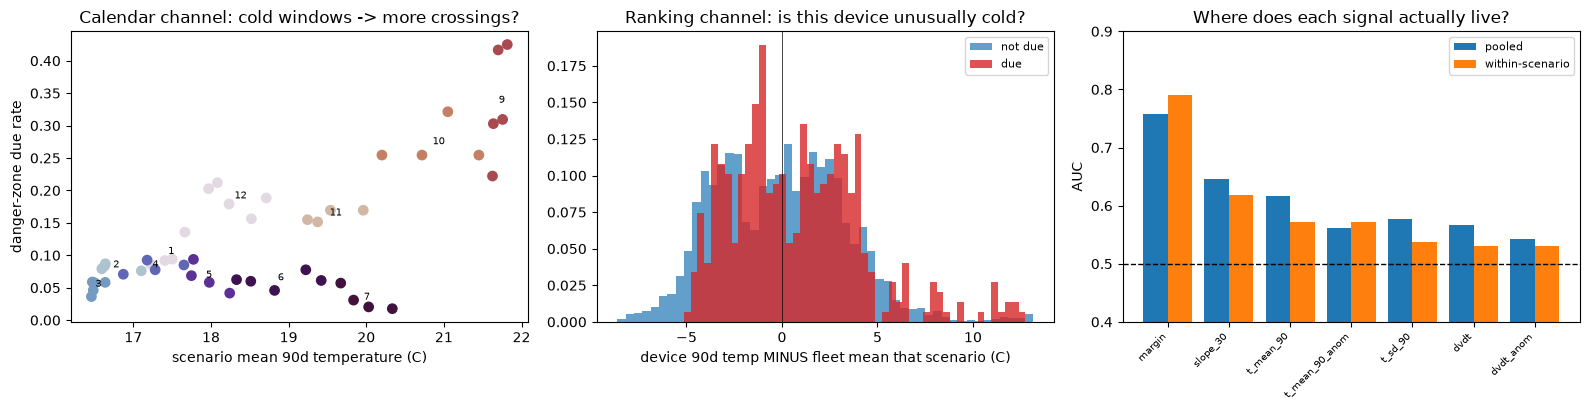

In [15]:
# Step 5: is the temperature signal battery-level or calendar-level?
# Expects: F (from Step 4), np, pd, plt
from sklearn.metrics import roc_auc_score

dz = F[F.margin < 0.20].copy()
dz["mbin"] = pd.qcut(dz.margin, 6, duplicates="drop")

# --- device-level ANOMALIES: strip the calendar component ---
for c in ["t_mean_90", "t_sd_90", "dvdt"]:
    dz[c + "_anom"]  = dz[c] - dz.groupby("scenario")[c].transform("mean")   # vs fleet, same date
    dz[c + "_bpeer"] = dz[c] - dz.groupby(["scenario","building"])[c].transform("mean")  # vs building peers

def within_scenario_auc(frame, col, min_due=3):
    """AUC computed inside each scenario separately, then averaged.
    Direction fixed globally so noise cannot inflate it."""
    g0 = frame.dropna(subset=[col])
    glob = roc_auc_score(g0.due, g0[col]); sign = 1 if glob >= 0.5 else -1
    a = []
    for _, g in g0.groupby("scenario"):
        if g.due.sum() >= min_due and g.due.nunique() == 2 and g[col].nunique() > 3:
            a.append(roc_auc_score(g.due, sign * g[col]))
    return (np.mean(a) if a else np.nan), len(a)

print(f"--- pooled vs WITHIN-SCENARIO AUC, danger zone (n={len(dz)}, due={int(dz.due.sum())}) ---")
print(f"{'feature':22s} {'pooled':>8s} {'within':>8s} {'#scen':>6s}")
for c in ["margin", "slope_30", "slope_60",
          "t_mean_90", "t_mean_90_anom", "t_mean_90_bpeer",
          "t_sd_90",   "t_sd_90_anom",
          "dvdt",      "dvdt_anom",      "dvdt_bpeer"]:
    if c not in dz: continue
    g0 = dz.dropna(subset=[c])
    if g0.due.nunique() < 2: continue
    p = roc_auc_score(g0.due, g0[c]); p = max(p, 1 - p)
    w, n = within_scenario_auc(dz, c)
    print(f"{c:22s} {p:8.3f} {w:8.3f} {n:6d}")

# --- the calendar channel, measured directly ---
sc_lvl = dz.groupby("scenario").agg(due_rate=("due","mean"), n=("due","size"),
                                    t90=("t_mean_90","mean"), margin=("margin","mean"),
                                    month=("cutoff", lambda s: pd.Timestamp(s.iloc[0]).month))
print(f"\n--- scenario level (n={len(sc_lvl)} scenarios) ---")
print(f"corr(due_rate, mean t_mean_90) = {sc_lvl.due_rate.corr(sc_lvl.t90):.3f}")
print(f"corr(due_rate, mean margin)    = {sc_lvl.due_rate.corr(sc_lvl.margin):.3f}")
print("\ndue rate in danger zone by window month:")
print(sc_lvl.groupby("month").agg(due_rate=("due_rate","mean"), t90=("t90","mean"),
                                  n_scen=("due_rate","size")).round(3).to_string())

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(sc_lvl.t90, sc_lvl.due_rate, c=sc_lvl.month, cmap="twilight", s=45)
ax[0].set_xlabel("scenario mean 90d temperature (C)"); ax[0].set_ylabel("danger-zone due rate")
ax[0].set_title("Calendar channel: cold windows -> more crossings?")
for m, g in sc_lvl.groupby("month"):
    ax[0].annotate(str(m), (g.t90.mean(), g.due_rate.mean()), fontsize=7)

d2 = dz.dropna(subset=["t_mean_90_anom"])
ax[1].hist(d2.loc[~d2.due, "t_mean_90_anom"], bins=50, density=True, alpha=.7, label="not due")
ax[1].hist(d2.loc[ d2.due, "t_mean_90_anom"], bins=50, density=True, alpha=.8, color="tab:red", label="due")
ax[1].axvline(0, color="k", lw=.5)
ax[1].set_xlabel("device 90d temp MINUS fleet mean that scenario (C)")
ax[1].set_title("Ranking channel: is this device unusually cold?"); ax[1].legend(fontsize=8)

names, pooled, within = [], [], []
for c in ["margin","slope_30","t_mean_90","t_mean_90_anom","t_sd_90","dvdt","dvdt_anom"]:
    g0 = dz.dropna(subset=[c])
    if g0.due.nunique() < 2: continue
    p = roc_auc_score(g0.due, g0[c]); names.append(c)
    pooled.append(max(p, 1-p)); within.append(within_scenario_auc(dz, c)[0])
x = np.arange(len(names))
ax[2].bar(x-0.2, pooled, 0.4, label="pooled")
ax[2].bar(x+0.2, within, 0.4, label="within-scenario")
ax[2].axhline(0.5, color="k", ls="--", lw=1)
ax[2].set_xticks(x); ax[2].set_xticklabels(names, rotation=45, ha="right", fontsize=7)
ax[2].set_ylim(0.4, 0.9); ax[2].set_ylabel("AUC"); ax[2].legend(fontsize=8)
ax[2].set_title("Where does each signal actually live?")
plt.tight_layout(); plt.show()

In [17]:
# rebuild the scenario table in this notebook
import json
with open(DATA_DIR / "scenarios.json") as fh:
    scenarios_raw = json.load(fh)

DATA_END = pd.to_datetime(sm.date).max()          # last day with a smoothed value
sc = pd.DataFrame([{"scenario": s["name"],
                    "cutoff": pd.Timestamp(s["start_time"])} for s in scenarios_raw])
sc["window_end"]      = sc.cutoff + pd.Timedelta(days=HOR)
sc["observable_days"] = ((sc.window_end.clip(upper=DATA_END) - sc.cutoff)
                         .dt.total_seconds() / 86400).clip(lower=0)
sc["obs_frac"]        = sc.observable_days / HOR
print("scenarios:", len(sc), "| fully observable:", int((sc.obs_frac >= 1).sum()))

scenarios: 48 | fully observable: 42


within-day table: (360847, 10) | beta_day valid: 0.938
feature table: (19890, 48)

--- WITHIN-SCENARIO AUC in the danger zone (n=3368, due=396) ---
  margin           0.781   (n=3368)
  slope_60         0.588   (n=2863)
  dwell_50         0.723   (n=3368)
  dwell_45         0.669   (n=3368)
  days_below_50    0.750   (n=3368)
  days_near_now    0.587   (n=3368)
  fresh_low        nan   (n=3368)
  above_rmin       0.512   (n=3368)
  t_anom           0.528   (n=3296)
  beta_wd_30       0.551   (n=3368)
  beta_wd_90       0.557   (n=3368)
  beta_wd_rel      0.557   (n=3368)
  beta_wd_trend    0.508   (n=3368)
  vrange_90        0.532   (n=3368)

--- the 80%-vs-18% dwell claim, tested on our data ---
  fresh dip (<=14d below 2.50): n=  30  due rate 0.667
  long dwell (>43d below 2.50): n= 293  due rate 0.246

--- recall@16 over the FULL active fleet (42 scenarios) ---
  V10 reference (from report)      0.601
  margin only                      0.552
  margin + 42*slope_60             0.488


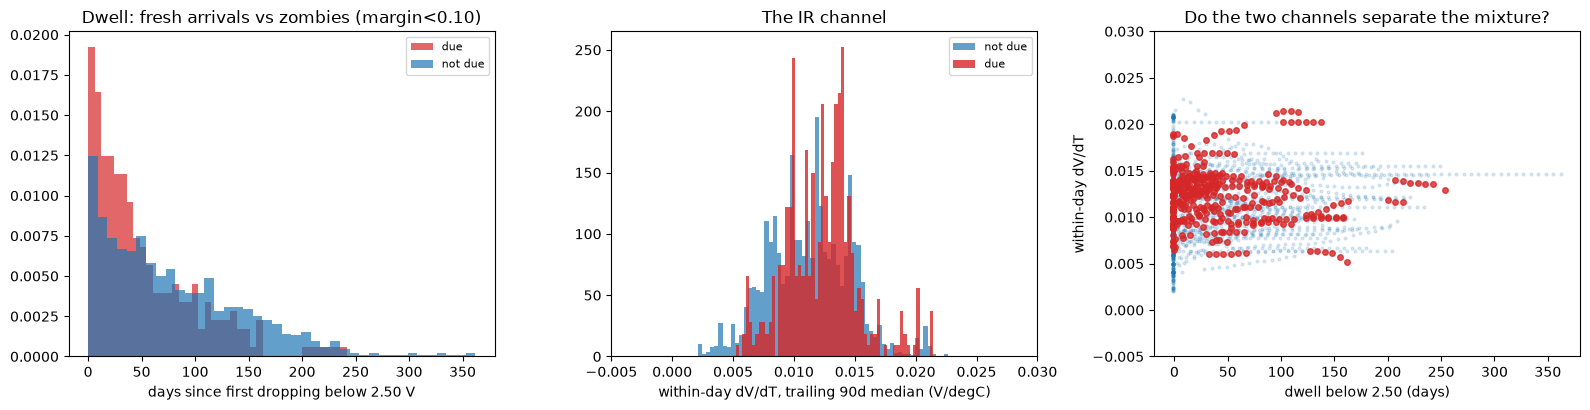

In [18]:
# Step 6: dwell + within-day features, scored on recall@16
# Expects: sm, d, feat/F, devices, eol_s, DATA_DIR, CACHE, pl, pd, np, plt
import numpy as np, pandas as pd, matplotlib.pyplot as plt, polars as pl, warnings
from pathlib import Path
from sklearn.metrics import roc_auc_score
warnings.filterwarnings("ignore")
V_EOL, HOR, K_OP = 2.4, 42, 16

# ---------- 1. WITHIN-DAY features from the raw hourly series (one pass, cached) ----------
WD_PATH = CACHE / "within_day.parquet"
if WD_PATH.exists():
    wd = pl.read_parquet(WD_PATH)
else:
    wd = (pl.scan_parquet(DATA_DIR / "battery_metrics.parquet")
      .with_columns([pl.col("end_time").dt.date().alias("date"),
                     pl.col("voltage").cast(pl.Float64),
                     pl.col("temperature").cast(pl.Float64)])
      .group_by(["device_id", "date"])
      .agg([pl.len().alias("n"),
            pl.col("voltage").mean().alias("vm"), pl.col("temperature").mean().alias("tm"),
            (pl.col("voltage") * pl.col("temperature")).mean().alias("vtm"),
            (pl.col("temperature") ** 2).mean().alias("t2m"),
            (pl.col("voltage").max() - pl.col("voltage").min()).alias("v_range"),
            (pl.col("temperature").max() - pl.col("temperature").min()).alias("t_range")])
      .with_columns(((pl.col("vtm") - pl.col("vm") * pl.col("tm")) /
                     (pl.col("t2m") - pl.col("tm") ** 2)).alias("beta_day"))
      .sort(["device_id", "date"]).collect())
    wd.write_parquet(WD_PATH)
W = wd.to_pandas(); W["date"] = pd.to_datetime(W["date"])
W.loc[(W.n < 6) | (W.t_range < 0.5), "beta_day"] = np.nan     # unreliable within-day fits
print("within-day table:", W.shape, "| beta_day valid:", W.beta_day.notna().mean().round(3))

# ---------- 2. per-device arrays ----------
SM = {}
for dev, g in sm.groupby("device_id", observed=True):
    g = g.sort_values("date")
    SM[dev] = (pd.to_datetime(g.date).values.astype("datetime64[D]").astype(int),
               g.v_smooth.values, g.t_daily.values)
WDv = {}
for dev, g in W.groupby("device_id", observed=True):
    g = g.sort_values("date")
    WDv[dev] = (pd.to_datetime(g.date).values.astype("datetime64[D]").astype(int),
                g.beta_day.values, g.v_range.values, g.t_range.values)

# b(v): sensitivity by voltage level, measured in Step 2 block C
def b_of_v(v):
    return np.interp(v, [2.45, 2.55, 2.65, 2.75, 2.85, 2.95, 3.05],
                        [0.01646, 0.01287, 0.01287, 0.01145, 0.00782, 0.00586, 0.00394])

base = F if "F" in dir() else feat
rows = []
for (scen, cut), grp in base.groupby(["scenario", "cutoff"]):
    ci = np.datetime64(pd.Timestamp(cut), "D").astype(int)
    for dev in grp.device_id:
        r = {"scenario": scen, "device_id": dev}
        t, v, tt = SM[dev]
        k = np.searchsorted(t, ci, side="right")
        if k >= 10:
            v_, t_, tt_ = v[:k], t[:k], tt[:k]
            ok = np.isfinite(v_); vo, to = v_[ok], t_[ok]
            if len(vo) >= 5:
                now = vo[-1]
                # --- DWELL: how long has it been down here? ---
                for thr, nm in [(2.45, "45"), (2.50, "50"), (2.55, "55")]:
                    below = vo < thr
                    r[f"days_below_{nm}"] = int(below.sum())
                    r[f"dwell_{nm}"] = int(ci - to[below][0]) if below.any() else -1
                rmin = np.minimum.accumulate(vo)[-1]
                r["fresh_low"]  = float(now <= rmin + 0.002)     # at its all-time low now
                r["above_rmin"] = now - rmin
                # time spent within 20 mV of the current level (the "kissing" signature)
                r["days_near_now"] = int((np.abs(vo - now) < 0.02).sum())
                # --- expected seasonal dT over the coming window, from PRIOR years ---
                dts = []
                for yr in (1, 2, 3):
                    a = np.searchsorted(t_, ci - 365*yr); b_ = np.searchsorted(t_, ci - 365*yr + HOR)
                    if a < len(tt_) and b_ < len(tt_) and np.isfinite(tt_[a]) and np.isfinite(tt_[b_]):
                        dts.append(tt_[b_] - tt_[a])
                r["E_dT"] = np.mean(dts) if dts else np.nan
                r["t_now"] = np.nanmean(tt_[max(0, k-30):k])
        # --- WITHIN-DAY: trailing medians of the daily dV/dT and ranges ---
        if dev in WDv:
            tw, bd, vr, tr = WDv[dev]
            j = np.searchsorted(tw, ci, side="right")
            for win, nm in [(30, "30"), (90, "90")]:
                s = slice(max(0, j-win), j)
                r[f"beta_wd_{nm}"] = np.nanmedian(bd[s]) if j > 0 else np.nan
                r[f"vrange_{nm}"]  = np.nanmedian(vr[s]) if j > 0 else np.nan
            if j > 120:
                old = np.nanmedian(bd[max(0, j-180):j-90]); new = np.nanmedian(bd[max(0, j-90):j])
                r["beta_wd_trend"] = new - old               # is IR rising?
        rows.append(r)
X = base.merge(pd.DataFrame(rows), on=["scenario", "device_id"], how="left")
X["t_anom"] = X.t_now - X.groupby("scenario")["t_now"].transform("mean")
X["beta_wd_rel"] = X.beta_wd_90 / X.groupby("scenario")["beta_wd_90"].transform("median")
print("feature table:", X.shape)

# ---------- 3. the three scores, plus the formula ----------
X["S_margin"] = -X.margin
X["S_drift"]  = -(X.margin + HOR * X.slope_60.fillna(0))
X["S_full"]   = -(X.margin - b_of_v(X.v_last) * X.t_anom.fillna(0)
                          + HOR * X.slope_60.fillna(0)
                          + b_of_v(X.v_last) * X.E_dT.fillna(0))

# ---------- 4. evaluation on the population that matters ----------
FULL = set(sc.scenario[sc.obs_frac >= 1])
Z = X[X.scenario.isin(FULL)].copy()
dz = Z[Z.margin < 0.20].copy()

def wsc_auc(fr, col, min_due=3):
    g0 = fr.dropna(subset=[col]);  s = 1 if roc_auc_score(g0.due, g0[col]) >= 0.5 else -1
    a = [roc_auc_score(g.due, s*g[col]) for _, g in g0.groupby("scenario")
         if g.due.sum() >= min_due and g.due.nunique() == 2 and g[col].nunique() > 3]
    return np.mean(a) if a else np.nan

print(f"\n--- WITHIN-SCENARIO AUC in the danger zone (n={len(dz)}, due={int(dz.due.sum())}) ---")
for c in ["margin","slope_60","dwell_50","dwell_45","days_below_50","days_near_now",
          "fresh_low","above_rmin","t_anom","beta_wd_30","beta_wd_90","beta_wd_rel",
          "beta_wd_trend","vrange_90"]:
    if c in dz and dz[c].notna().sum() > 500:
        print(f"  {c:16s} {wsc_auc(dz, c):.3f}   (n={int(dz[c].notna().sum())})")

print("\n--- the 80%-vs-18% dwell claim, tested on our data ---")
fresh = dz[(dz.margin < 0.05) & (dz.dwell_50.between(0, 14))]
old   = dz[(dz.margin < 0.05) & (dz.dwell_50 > 43)]
print(f"  fresh dip (<=14d below 2.50): n={len(fresh):4d}  due rate {fresh.due.mean():.3f}")
print(f"  long dwell (>43d below 2.50): n={len(old):4d}  due rate {old.due.mean():.3f}")

def recall_at(fr, col, K=K_OP):
    out = []
    for _, g in fr.groupby("scenario"):
        g = g.dropna(subset=[col])
        out.append(g.nlargest(K, col).due.sum() / max(g.due.sum(), 1))
    return np.mean(out)

print(f"\n--- recall@{K_OP} over the FULL active fleet ({len(FULL)} scenarios) ---")
print(f"  {'V10 reference (from report)':32s} 0.601")
for nm, c in [("margin only","S_margin"), ("margin + 42*slope_60","S_drift"),
              ("full formula (temp+season)","S_full")]:
    print(f"  {nm:32s} {recall_at(Z, c):.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
sub = dz[dz.margin < 0.10]
for lab, m, col in [("due", sub.due, "tab:red"), ("not due", ~sub.due, "tab:blue")]:
    ax[0].hist(sub.loc[m, "dwell_50"].clip(-1, 400), bins=40, density=True, alpha=.7, label=lab, color=col)
ax[0].set_xlabel("days since first dropping below 2.50 V"); ax[0].legend(fontsize=8)
ax[0].set_title("Dwell: fresh arrivals vs zombies (margin<0.10)")

b2 = dz.dropna(subset=["beta_wd_90"])
ax[1].hist(b2.loc[~b2.due, "beta_wd_90"], bins=60, density=True, alpha=.7, label="not due")
ax[1].hist(b2.loc[ b2.due, "beta_wd_90"], bins=60, density=True, alpha=.8, color="tab:red", label="due")
ax[1].set_xlim(-0.005, 0.03); ax[1].set_xlabel("within-day dV/dT, trailing 90d median (V/degC)")
ax[1].set_title("The IR channel"); ax[1].legend(fontsize=8)

ax[2].scatter(dz.loc[~dz.due,"dwell_50"].clip(-1,400), dz.loc[~dz.due,"beta_wd_90"], s=4, alpha=.15)
ax[2].scatter(dz.loc[ dz.due,"dwell_50"].clip(-1,400), dz.loc[ dz.due,"beta_wd_90"], s=16, alpha=.8, color="tab:red")
ax[2].set_ylim(-0.005, 0.03); ax[2].set_xlabel("dwell below 2.50 (days)")
ax[2].set_ylabel("within-day dV/dT"); ax[2].set_title("Do the two channels separate the mixture?")
plt.tight_layout(); plt.show()

--- due rate and dwell effect WITHIN margin strata ---
margin band           n   due   rate |  fresh<=14d  dwell>43d  ratio
(0.0, 0.025]        187    65  0.348 |  0.692( 13)  0.239(142)   2.89
(0.025, 0.05]       234    85  0.363 |  0.647( 17)  0.252(151)   2.57
(0.05, 0.075]       419    73  0.174 |  0.375( 48)  0.129(278)   2.90
(0.075, 0.1]        382    69  0.181 |  0.239(142)  0.112(143)   2.14
(0.1, 0.15]        1021    64  0.063 |  0.103( 29)  0.079(177)   1.31
(0.15, 0.2]        1125    40  0.036 |  0.143(  7)  0.033( 60)   4.29

--- within-scenario AUC of dwell, computed INSIDE each margin stratum ---
  (0.0, 0.025]     n=  187 due=  65  dwell_50=0.831  days_below_50=0.664  beta_wd_90=0.683
  (0.025, 0.05]    n=  234 due=  85  dwell_50=0.727  days_below_50=0.655  beta_wd_90=0.603
  (0.05, 0.075]    n=  419 due=  73  dwell_50=0.437  days_below_50=0.425  beta_wd_90=0.449
  (0.075, 0.1]     n=  382 due=  69  dwell_50=0.426  days_below_50=0.427  beta_wd_90=0.691
  (0.1, 0.15]    

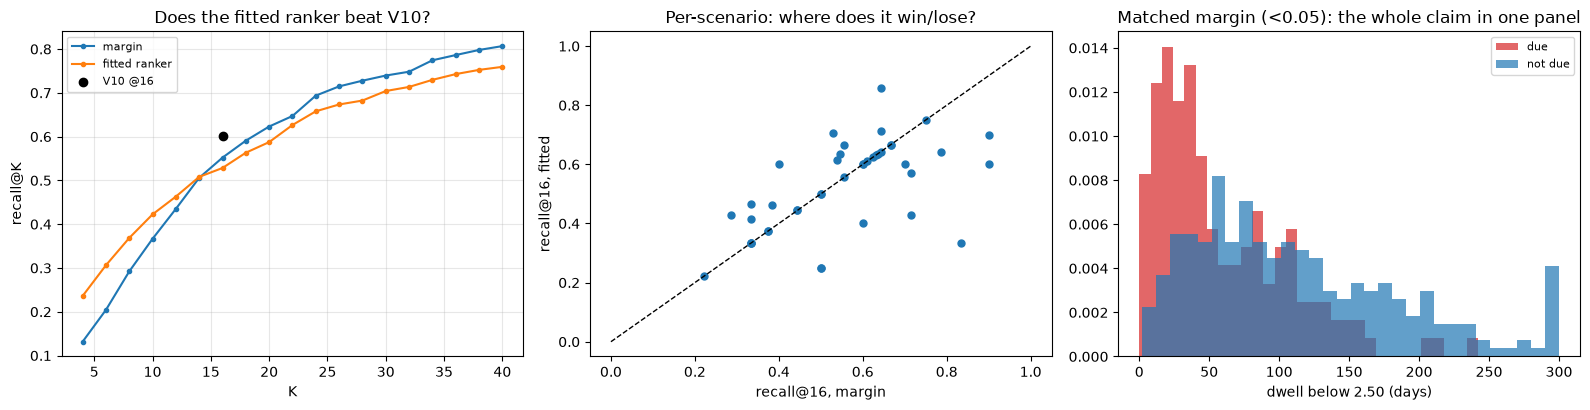

In [19]:
# Step 7: does dwell add beyond margin, and can a fitted ranker beat 0.601?
# Expects: X, Z, sc, np, pd, plt
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
SEED = 0

def wsc_auc(fr, col, min_due=3):                      # fixed: allow binary features
    g0 = fr.dropna(subset=[col])
    if g0.due.nunique() < 2 or g0[col].nunique() < 2: return np.nan
    s = 1 if roc_auc_score(g0.due, g0[col]) >= 0.5 else -1
    a = [roc_auc_score(g.due, s * g[col]) for _, g in g0.groupby("scenario")
         if g.due.sum() >= min_due and g.due.nunique() == 2 and g[col].nunique() >= 2]
    return np.mean(a) if a else np.nan

# ---------- A. does dwell survive conditioning on margin? ----------
dz = Z[Z.margin < 0.20].copy()
dz["mstrat"] = pd.cut(dz.margin, [0, .025, .05, .075, .10, .15, .20])
print("--- due rate and dwell effect WITHIN margin strata ---")
print(f"{'margin band':16s} {'n':>6s} {'due':>5s} {'rate':>6s} | "
      f"{'fresh<=14d':>11s} {'dwell>43d':>10s} {'ratio':>6s}")
for b, g in dz.groupby("mstrat", observed=True):
    fr = g[g.dwell_50.between(0, 14)]; ol = g[g.dwell_50 > 43]
    r = (fr.due.mean() / ol.due.mean()) if len(ol) and ol.due.mean() > 0 else np.nan
    print(f"{str(b):16s} {len(g):6d} {int(g.due.sum()):5d} {g.due.mean():6.3f} | "
          f"{fr.due.mean() if len(fr) else np.nan:6.3f}({len(fr):3d}) "
          f"{ol.due.mean() if len(ol) else np.nan:6.3f}({len(ol):3d}) {r:6.2f}")

print("\n--- within-scenario AUC of dwell, computed INSIDE each margin stratum ---")
for b, g in dz.groupby("mstrat", observed=True):
    if g.due.sum() < 20: continue
    print(f"  {str(b):16s} n={len(g):5d} due={int(g.due.sum()):4d}  "
          f"dwell_50={wsc_auc(g,'dwell_50'):.3f}  days_below_50={wsc_auc(g,'days_below_50'):.3f}  "
          f"beta_wd_90={wsc_auc(g,'beta_wd_90'):.3f}")

# ---------- B. fitted ranker, out-of-fold BY BUILDING ----------
FEATS = ["margin","v_last","slope_14","slope_30","slope_60","slope_90",
         "dwell_50","dwell_45","days_below_50","days_below_55","days_near_now",
         "above_rmin","fresh_low","beta_wd_90","beta_wd_30","vrange_90",
         "t_anom","n_days_obs","age_days","v_runmin","days_since_runmin"]
FEATS = [c for c in FEATS if c in Z.columns]
CAND = Z[Z.margin < 0.25].copy()                      # Stage A: 98.6% recall
print(f"\ncandidates: {len(CAND)} rows, {int(CAND.due.sum())} due, "
      f"{CAND.groupby('scenario').size().mean():.0f}/scenario")

oof = np.full(len(CAND), np.nan)
gkf = GroupKFold(n_splits=5)
for tr, te in gkf.split(CAND, CAND.due, groups=CAND.building):
    m = HistGradientBoostingClassifier(max_depth=3, max_iter=250, learning_rate=0.05,
                                       min_samples_leaf=40, l2_regularization=1.0,
                                       random_state=SEED)
    m.fit(CAND.iloc[tr][FEATS], CAND.iloc[tr].due)
    oof[te] = m.predict_proba(CAND.iloc[te][FEATS])[:, 1]
CAND["p_oof"] = oof

# ---------- C. evaluation ----------
def recall_at(fr, col, K):
    return np.mean([g.nlargest(K, col).due.sum() / max(g.due.sum(), 1)
                    for _, g in fr.groupby("scenario")])
def prec_at(fr, col, K):
    return np.mean([g.nlargest(K, col).due.mean() for _, g in fr.groupby("scenario")])

Z2 = Z.merge(CAND[["scenario","device_id","p_oof"]], on=["scenario","device_id"], how="left")
Z2["p_oof"] = Z2.p_oof.fillna(-1)
Z2["S_margin"]      = -Z2.margin
Z2["S_margin_dwell"] = -(Z2.margin + 0.0004 * Z2.dwell_50.clip(lower=0))   # crude hand rule

print(f"\n{'score':28s} {'R@12':>7s} {'R@16':>7s} {'R@20':>7s} {'P@16':>7s}")
print(f"{'V10 (from report)':28s} {'-':>7s} {0.601:7.3f} {'-':>7s} {0.354:7.3f}")
for nm, c in [("margin only","S_margin"), ("margin + dwell (hand)","S_margin_dwell"),
              ("fitted ranker (OOF/building)","p_oof")]:
    print(f"{nm:28s} " + " ".join(f"{recall_at(Z2,c,K):7.3f}" for K in (12,16,20))
          + f" {prec_at(Z2,c,16):7.3f}")

imp = pd.Series(m.feature_importances_ if hasattr(m,"feature_importances_") else np.nan,
                index=FEATS).sort_values(ascending=False) if hasattr(m,"feature_importances_") else None
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ks = list(range(4, 41, 2))
for nm, c in [("margin","S_margin"), ("fitted ranker","p_oof")]:
    ax[0].plot(ks, [recall_at(Z2, c, K) for K in ks], marker="o", ms=3, label=nm)
ax[0].scatter([16],[0.601], color="k", zorder=5, label="V10 @16")
ax[0].set_xlabel("K"); ax[0].set_ylabel("recall@K"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
ax[0].set_title("Does the fitted ranker beat V10?")

per = pd.DataFrame({"scenario": [s for s,_ in Z2.groupby("scenario")],
                    "margin": [g.nlargest(16,"S_margin").due.sum()/max(g.due.sum(),1) for _,g in Z2.groupby("scenario")],
                    "fitted": [g.nlargest(16,"p_oof").due.sum()/max(g.due.sum(),1) for _,g in Z2.groupby("scenario")]})
ax[1].scatter(per.margin, per.fitted, s=25); ax[1].plot([0,1],[0,1],"k--",lw=1)
ax[1].set_xlabel("recall@16, margin"); ax[1].set_ylabel("recall@16, fitted")
ax[1].set_title("Per-scenario: where does it win/lose?")

sub = dz[dz.margin < 0.05]
for lab, m_, col in [("due", sub.due, "tab:red"), ("not due", ~sub.due, "tab:blue")]:
    ax[2].hist(sub.loc[m_, "dwell_50"].clip(0, 300), bins=30, density=True, alpha=.7, label=lab, color=col)
ax[2].set_xlabel("dwell below 2.50 (days)"); ax[2].legend(fontsize=8)
ax[2].set_title("Matched margin (<0.05): the whole claim in one panel")
plt.tight_layout(); plt.show()

V10 on the same 42 scenarios: recall = 0.582  (mean served 15.7)

score                             R@12    R@16   R@varK    P@16
V10 (variable K, actual)             -       -    0.582   0.354
margin only                      0.435   0.552    0.547   0.354
margin + dwell (hand)            0.482   0.552    0.574   0.354
logistic, 2 features             0.357   0.460    0.464   0.304
logistic, 5 features             0.382   0.461    0.466   0.302
small GBM, 5 features            0.415   0.494    0.506   0.327

2-feature logit:  logit(p) = -1.74 + -0.705*log(margin) + -0.529*log1p(dwell)


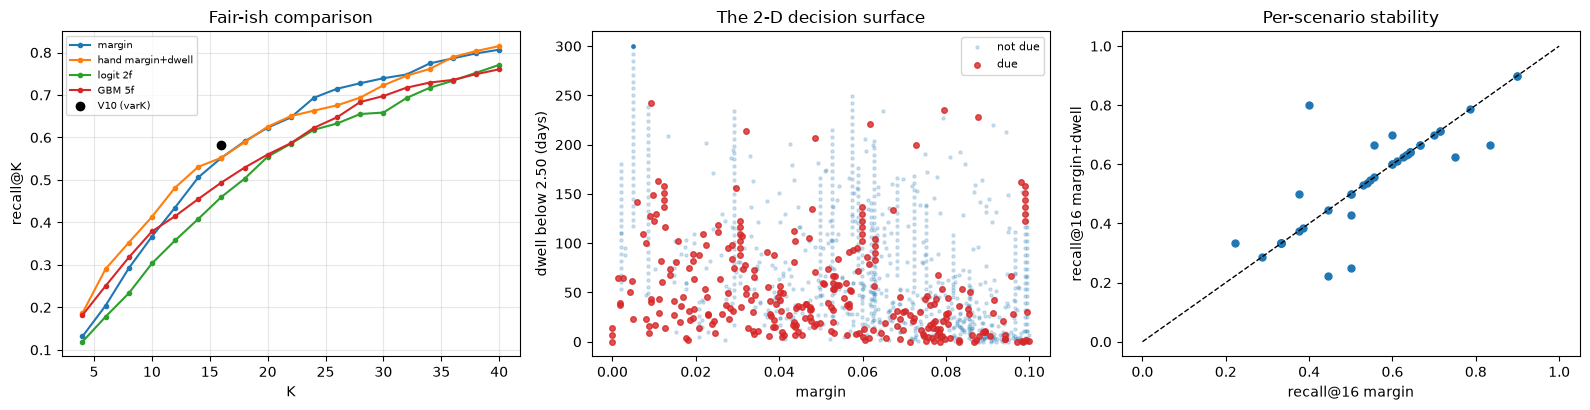

In [23]:
# Step 8: fair comparison + a model sized to the real sample
import json
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import HistGradientBoostingClassifier
SEED = 0

# ---------- 0. fix the dwell encoding ----------
for c in ["dwell_50", "dwell_45"]:
    Z[c + "_f"] = Z[c].where(Z[c] >= 0, np.nan)          # "never below" -> NaN, not "fresh"
    Z["ever_" + c] = (Z[c] >= 0).astype(float)
Z["log_dwell50"] = np.log1p(Z.dwell_50_f.fillna(400))
Z["log_margin"]  = np.log(Z.margin.clip(lower=0.001))

# ---------- 1. V10's actual per-scenario swap counts ----------
rep = json.load(open(Path("../docs") / "v10_validation_report.json"))
V10 = pd.DataFrame([{ "scenario": s["scenario"], "served": s["served"],
                      "due": s["due"], "hit": s["hit"]} for s in rep["scenarios"]])
Kmap = dict(zip(V10.scenario, V10.served))
v10_sub = V10[V10.scenario.isin(Z.scenario.unique())]
print(f"V10 on the same {len(v10_sub)} scenarios: recall = "
      f"{(v10_sub.hit.sum()/v10_sub.due.sum()):.3f}  (mean served {v10_sub.served.mean():.1f})")

def recall_varK(fr, col, kmap):
    out = []
    for s, g in fr.groupby("scenario"):
        K = int(kmap.get(s, 16))
        out.append(g.nlargest(K, col).due.sum() / max(g.due.sum(), 1))
    return np.mean(out)

# ---------- 2. small models, OOF by building, scenario-balanced ----------
CAND = Z[Z.margin < 0.25].copy()
w = CAND.groupby("scenario")["due"].transform(lambda s: 1.0 / max(s.sum(), 1))   # each scenario equal
w = w / w.mean()

SMALL = ["log_margin", "log_dwell50"]                       # 2 features
MED   = ["log_margin", "log_dwell50", "slope_60", "beta_wd_90", "days_below_50"]

def oof(features, model_fn, weights=None):
    p = np.full(len(CAND), np.nan)
    for tr, te in GroupKFold(n_splits=5).split(CAND, CAND.due, groups=CAND.building):
        m = model_fn()
        Xtr = CAND.iloc[tr][features].fillna(CAND[features].median())
        kw = {"sample_weight": weights.iloc[tr].values} if weights is not None else {}
        m.fit(Xtr, CAND.iloc[tr].due, **kw)
        p[te] = m.predict_proba(CAND.iloc[te][features].fillna(CAND[features].median()))[:, 1]
    return p

CAND["p_lr2"]  = oof(SMALL, lambda: LogisticRegression(max_iter=1000), w)
CAND["p_lr5"]  = oof(MED,   lambda: LogisticRegression(max_iter=1000), w)
CAND["p_gb"]   = oof(MED,   lambda: HistGradientBoostingClassifier(
                        max_depth=2, max_iter=120, learning_rate=0.06,
                        min_samples_leaf=80, l2_regularization=5.0, random_state=SEED), w)

Z2 = Z.merge(CAND[["scenario","device_id","p_lr2","p_lr5","p_gb"]],
             on=["scenario","device_id"], how="left")
for c in ["p_lr2","p_lr5","p_gb"]: Z2[c] = Z2[c].fillna(-1)
Z2["S_margin"] = -Z2.margin
# hand rule: margin penalised by how long it has been sitting there
Z2["S_hand"]   = -(Z2.margin + 0.00035 * Z2.dwell_50_f.fillna(400).clip(0, 400))

print(f"\n{'score':30s} {'R@12':>7s} {'R@16':>7s} {'R@varK':>8s} {'P@16':>7s}")
print(f"{'V10 (variable K, actual)':30s} {'-':>7s} {'-':>7s} "
      f"{(v10_sub.hit.sum()/v10_sub.due.sum()):8.3f} {0.354:7.3f}")
for nm, c in [("margin only","S_margin"), ("margin + dwell (hand)","S_hand"),
              ("logistic, 2 features","p_lr2"), ("logistic, 5 features","p_lr5"),
              ("small GBM, 5 features","p_gb")]:
    print(f"{nm:30s} " + " ".join(f"{recall_at(Z2,c,K):7.3f}" for K in (12,16))
          + f" {recall_varK(Z2,c,Kmap):8.3f} {prec_at(Z2,c,16):7.3f}")

lr = LogisticRegression(max_iter=1000).fit(
        CAND[SMALL].fillna(CAND[SMALL].median()), CAND.due, sample_weight=w.values)
print(f"\n2-feature logit:  logit(p) = {lr.intercept_[0]:.2f} "
      f"+ {lr.coef_[0][0]:.3f}*log(margin) + {lr.coef_[0][1]:.3f}*log1p(dwell)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ks = list(range(4, 41, 2))
for nm, c in [("margin","S_margin"), ("hand margin+dwell","S_hand"),
              ("logit 2f","p_lr2"), ("GBM 5f","p_gb")]:
    ax[0].plot(ks, [recall_at(Z2, c, K) for K in ks], marker="o", ms=3, label=nm)
ax[0].scatter([16], [v10_sub.hit.sum()/v10_sub.due.sum()], color="k", zorder=5, label="V10 (varK)")
ax[0].set_xlabel("K"); ax[0].set_ylabel("recall@K"); ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)
ax[0].set_title("Fair-ish comparison")

g = Z2[Z2.margin < 0.10]
ax[1].scatter(g.loc[~g.due,"margin"], g.loc[~g.due,"dwell_50_f"].clip(0,300), s=5, alpha=.2, label="not due")
ax[1].scatter(g.loc[ g.due,"margin"], g.loc[ g.due,"dwell_50_f"].clip(0,300), s=16, alpha=.8,
              color="tab:red", label="due")
ax[1].set_xlabel("margin"); ax[1].set_ylabel("dwell below 2.50 (days)")
ax[1].set_title("The 2-D decision surface"); ax[1].legend(fontsize=8)

per = pd.DataFrame({"m": [g.nlargest(16,"S_margin").due.sum()/max(g.due.sum(),1) for _,g in Z2.groupby("scenario")],
                    "h": [g.nlargest(16,"S_hand").due.sum()/max(g.due.sum(),1) for _,g in Z2.groupby("scenario")]})
ax[2].scatter(per.m, per.h, s=25); ax[2].plot([0,1],[0,1],"k--",lw=1)
ax[2].set_xlabel("recall@16 margin"); ax[2].set_ylabel("recall@16 margin+dwell")
ax[2].set_title("Per-scenario stability")
plt.tight_layout(); plt.show()

--- dwell coefficient sweep (recall@varK) ---
  a=0.00e+00  0.547 ##############
  a=1.00e-05  0.547 ##############
  a=1.30e-05  0.542 ############
  a=1.68e-05  0.542 ############
  a=2.18e-05  0.547 ##############
  a=2.82e-05  0.547 ##############
  a=3.65e-05  0.547 ##############
  a=4.73e-05  0.552 ###############
  a=6.13e-05  0.549 ##############
  a=7.94e-05  0.554 ################
  a=1.03e-04  0.561 ##################
  a=1.33e-04  0.566 ###################
  a=1.73e-04  0.563 ##################
  a=2.24e-04  0.571 #####################
  a=2.90e-04  0.580 ########################
  a=3.76e-04  0.572 #####################
  a=4.87e-04  0.564 ###################
  a=6.31e-04  0.535 ##########
  a=8.18e-04  0.519 #####
  a=1.06e-03  0.503 
  a=1.37e-03  0.477 
  a=1.78e-03  0.455 
  a=2.30e-03  0.432 
  a=2.99e-03  0.420 
  a=3.87e-03  0.404 
  a=5.01e-03  0.403 

  margin only (a=0): 0.547   best: 0.580 at a=2.90e-04
  V10 reference:     0.582
  values of a matching or beati

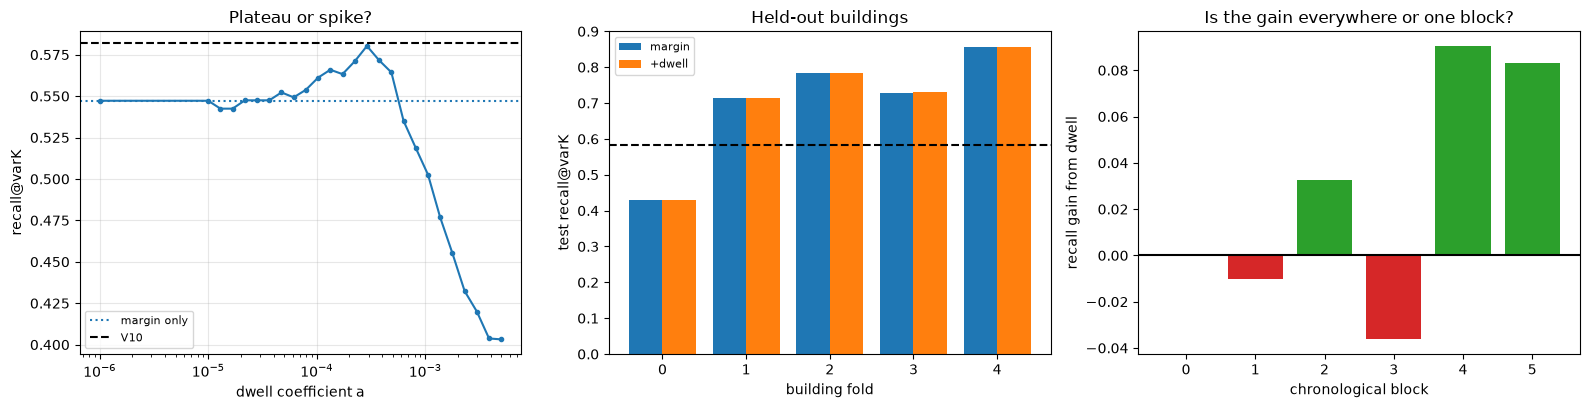

In [24]:
#Step 9: is the dwell coefficient robust, and can we beat 0.582 honestly?
# Expects: Z2, Kmap, v10_sub, np, pd, plt
from sklearn.model_selection import GroupKFold
V10_REF = v10_sub.hit.sum() / v10_sub.due.sum()

Z2["dwell_c"] = Z2.dwell_50_f.fillna(400).clip(0, 400)      # never-below -> max dwell
Z2["beta_c"]  = Z2.beta_wd_90.fillna(Z2.beta_wd_90.median())

def score(fr, a, b=0.0, cap=400):
    return -(fr.margin + a * fr.dwell_c.clip(0, cap) - b * fr.beta_c)

def rec_varK(fr, s, kmap=Kmap):
    fr = fr.assign(_s=s)
    return np.mean([g.nlargest(int(kmap.get(k, 16)), "_s").due.sum() / max(g.due.sum(), 1)
                    for k, g in fr.groupby("scenario")])

# ---------- A. sweep the dwell coefficient ----------
alphas = np.concatenate([[0], np.logspace(-5, -2.3, 25)])
curve = [rec_varK(Z2, score(Z2, a)) for a in alphas]
print("--- dwell coefficient sweep (recall@varK) ---")
for a, r in zip(alphas, curve):
    bar = "#" * int((r - 0.50) * 300) if r > 0.50 else ""
    print(f"  a={a:.2e}  {r:.3f} {bar}")
print(f"\n  margin only (a=0): {curve[0]:.3f}   best: {max(curve):.3f} at a={alphas[int(np.argmax(curve))]:.2e}")
print(f"  V10 reference:     {V10_REF:.3f}")
above = [(a, r) for a, r in zip(alphas, curve) if r >= V10_REF]
print(f"  values of a matching or beating V10: {len(above)} of {len(alphas)}"
      + (f"   range [{above[0][0]:.1e}, {above[-1][0]:.1e}]" if above else ""))

# ---------- B. HONEST out-of-fold: tune a on 4 building folds, score the 5th ----------
dev_bldg = Z2.groupby("device_id")["building"].first()
folds, oof_rows = list(GroupKFold(5).split(Z2, Z2.due, groups=Z2.building)), []
for i, (tr, te) in enumerate(folds):
    TR, TE = Z2.iloc[tr], Z2.iloc[te]
    best_a = alphas[int(np.argmax([rec_varK(TR, score(TR, a)) for a in alphas]))]
    oof_rows.append({"fold": i, "a_chosen": best_a,
                     "test_margin": rec_varK(TE, score(TE, 0)),
                     "test_dwell":  rec_varK(TE, score(TE, best_a)),
                     "n_bldg": TE.building.nunique(), "due": int(TE.due.sum())})
O = pd.DataFrame(oof_rows)
print("\n--- nested OOF by building: coefficient chosen on train folds only ---")
print(O.round(4).to_string(index=False))
print(f"  mean test recall  margin {O.test_margin.mean():.3f} -> +dwell {O.test_dwell.mean():.3f}"
      f"   (delta {O.test_dwell.mean()-O.test_margin.mean():+.3f})")

# ---------- C. chronological block stability ----------
blocks = np.array_split(sorted(Z2.scenario.unique(), key=lambda s: int(s.split("_")[1])), 6)
A_FIX = 0.00035
print("\n--- chronological blocks (a fixed at 3.5e-4) ---")
print(f"{'block':10s} {'scen':>5s} {'due':>5s} {'margin':>8s} {'+dwell':>8s} {'delta':>7s}")
for i, blk in enumerate(blocks):
    g = Z2[Z2.scenario.isin(blk)]
    rm, rd = rec_varK(g, score(g, 0)), rec_varK(g, score(g, A_FIX))
    print(f"block {i:<4d} {len(blk):5d} {int(g.due.sum()):5d} {rm:8.3f} {rd:8.3f} {rd-rm:+7.3f}")

# ---------- D. add the IR channel as a third term ----------
print("\n--- adding within-day dV/dT (grid, in-sample: upper bound only) ---")
best = None
for a in [0, 1e-4, 2e-4, 3.5e-4, 5e-4, 8e-4]:
    row = []
    for b in [0, 0.5, 1, 2, 4, 8]:
        r = rec_varK(Z2, score(Z2, a, b)); row.append(r)
        if best is None or r > best[0]: best = (r, a, b)
    print(f"  a={a:.1e} " + " ".join(f"{v:.3f}" for v in row))
print(f"  best in-sample: {best[0]:.3f} at a={best[1]:.1e}, b={best[2]}  (NOT a validated number)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].semilogx(np.maximum(alphas, 1e-6), curve, marker="o", ms=3)
ax[0].axhline(curve[0], color="tab:blue", ls=":", label="margin only")
ax[0].axhline(V10_REF, color="k", ls="--", label="V10")
ax[0].set_xlabel("dwell coefficient a"); ax[0].set_ylabel("recall@varK")
ax[0].set_title("Plateau or spike?"); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

ax[1].bar(np.arange(len(O))-0.2, O.test_margin, 0.4, label="margin")
ax[1].bar(np.arange(len(O))+0.2, O.test_dwell, 0.4, label="+dwell")
ax[1].axhline(V10_REF, color="k", ls="--"); ax[1].set_xlabel("building fold")
ax[1].set_ylabel("test recall@varK"); ax[1].legend(fontsize=8)
ax[1].set_title("Held-out buildings")

d = [rec_varK(Z2[Z2.scenario.isin(b)], score(Z2[Z2.scenario.isin(b)], A_FIX)) -
     rec_varK(Z2[Z2.scenario.isin(b)], score(Z2[Z2.scenario.isin(b)], 0)) for b in blocks]
ax[2].bar(range(len(d)), d, color=["tab:green" if x > 0 else "tab:red" for x in d])
ax[2].axhline(0, color="k"); ax[2].set_xlabel("chronological block")
ax[2].set_ylabel("recall gain from dwell"); ax[2].set_title("Is the gain everywhere or one block?")
plt.tight_layout(); plt.show()

devices.end_time: datetime64[ns] | eol_s: datetime64[ns] | Z2.cutoff: datetime64[ns]
--- A. spread of effective EOL among candidates ---
candidates: 4611 rows, 110/scenario
censored (eff_eol = dataset boundary + 30d): 73.3%

NOT-due candidates, days_to_eff_eol quantiles:
count    4196.0
mean      165.0
std        74.0
min       -86.0
10%        77.0
25%       105.0
50%       154.0
75%       217.0
90%       273.0
max       364.0

distinct eff_eol values among not-due candidates: 58
share sitting on the single global boundary: 79.5%

by scenario (a few), spread of days_to_eff among NOT-due candidates:
          min  median  max    std  size
scenario                               
s_0        47   134.0  364  129.0    40
s_18       51   238.0  238   58.0   105
s_27       12   175.0  175   33.0   120
s_36      -51   112.0  112   18.0   125
s_8        47   308.0  308   98.0    68

--- B. proxy cost model, margin ranking (compare to V10: early 740, late 986) ---
{'total': np.float64(2101.1), 

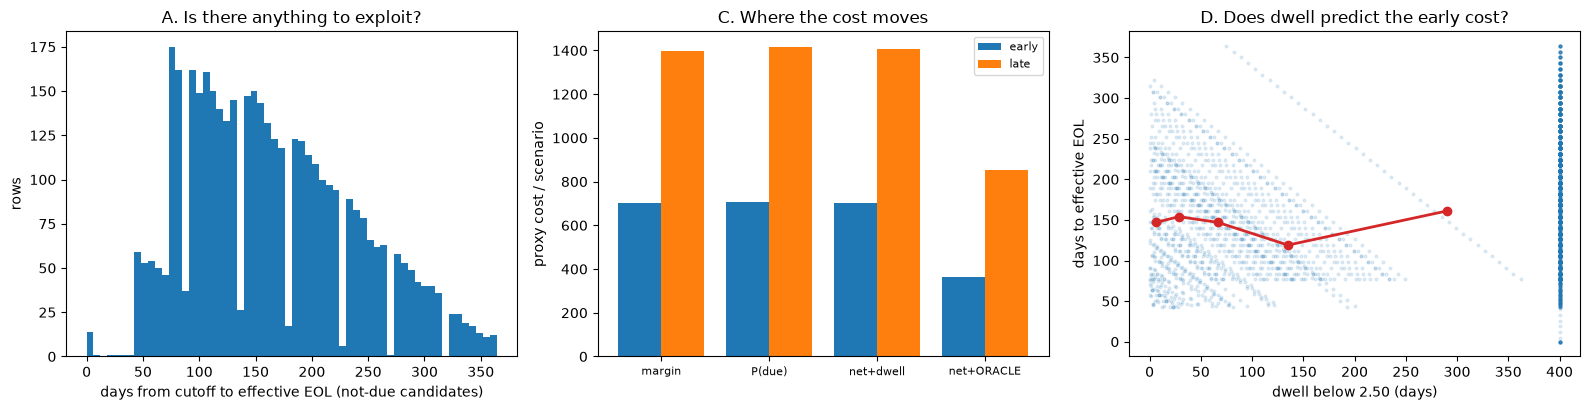

In [27]:
# Step 10: is there a per-battery EARLY-COST axis, and is dwell the way in?
# Expects: Z2, Kmap, devices, eol_s, sc, np, pd, plt
from sklearn.metrics import roc_auc_score
C_MISS   = 261.0      # measured: late_swap 986.04 / 3.77 missed per scenario
SWAP_OFF = 21         # assume selected batteries are swapped mid-window (see note)

# coerce the device timestamps properly (read_csv's parse_dates leaves these as objects)
for c in ["start_time", "end_time"]:
    devices[c] = pd.to_datetime(devices[c], format="ISO8601", utc=True).dt.tz_localize(None)

# make sure the other time columns are naive datetimes too
if not pd.api.types.is_datetime64_any_dtype(eol_s):
    eol_s = pd.to_datetime(eol_s)
if getattr(eol_s.dt, "tz", None) is not None:
    eol_s = eol_s.dt.tz_localize(None)

Z2["cutoff"] = pd.to_datetime(Z2["cutoff"])
if getattr(Z2["cutoff"].dt, "tz", None) is not None:
    Z2["cutoff"] = Z2["cutoff"].dt.tz_localize(None)

print("devices.end_time:", devices.end_time.dtype,
      "| eol_s:", eol_s.dtype, "| Z2.cutoff:", Z2.cutoff.dtype)

# ---------- effective EOL exactly as evaluate_plan() computes it ----------
end_t = devices.set_index("device_id")["end_time"]
eff = eol_s.copy()
unobs = eff.index[eff.isna()]
eff.loc[unobs] = (end_t.reindex(unobs) + pd.Timedelta(days=30)).dt.normalize()
Z2["eff_eol"]  = Z2.device_id.map(eff)
Z2["cut_naive"] = pd.to_datetime(Z2.cutoff).dt.tz_localize(None) if pd.to_datetime(Z2.cutoff).dt.tz is not None else pd.to_datetime(Z2.cutoff)
Z2["days_to_eff"] = (Z2.eff_eol - Z2.cut_naive).dt.days
Z2["is_censored"] = Z2.device_id.map(eol_s.isna())

# ---------- A. does the axis exist at all? ----------
CANDS = Z2[Z2.margin < 0.25].copy()
print("--- A. spread of effective EOL among candidates ---")
print(f"candidates: {len(CANDS)} rows, {CANDS.groupby('scenario').size().mean():.0f}/scenario")
print(f"censored (eff_eol = dataset boundary + 30d): {CANDS.is_censored.mean():.1%}")
nd = CANDS[~CANDS.due]
print(f"\nNOT-due candidates, days_to_eff_eol quantiles:")
print(nd.days_to_eff.describe(percentiles=[.1,.25,.5,.75,.9]).round(0).to_string())
print(f"\ndistinct eff_eol values among not-due candidates: {nd.eff_eol.nunique()}")
print(f"share sitting on the single global boundary: "
      f"{(nd.eff_eol == nd.eff_eol.mode()[0]).mean():.1%}")
print("\nby scenario (a few), spread of days_to_eff among NOT-due candidates:")
sp = nd.groupby("scenario").days_to_eff.agg(["min","median","max","std","size"])
print(sp.iloc[::10].round(0).to_string())

# ---------- B. proxy cost model ----------
def proxy_cost(fr, score_col, kmap=Kmap, swap_off=SWAP_OFF):
    """Select top-K per scenario; charge early/late on selected, emergency on missed dues."""
    early = late = miss = served = hits = 0.0
    for s, g in fr.groupby("scenario"):
        K = int(kmap.get(s, 16))
        sel = g.nlargest(K, score_col)
        d = sel.days_to_eff - swap_off                       # >0 early, <=0 late
        early += 0.5 * d.clip(lower=0).sum()
        late  += 10.0 * (-d.clip(upper=0)).sum()
        missed = g[g.due & ~g.index.isin(sel.index)].sort_values("device_id")
        for k, (_, r) in enumerate(missed.iterrows()):
            visit = 48 + k
            late += 10.0 * max(visit - r.days_to_eff, 0)
        miss += len(missed); served += K; hits += sel.due.sum()
    n = fr.scenario.nunique()
    return dict(total=(early+late)/n, early=early/n, late=late/n,
                served=served/n, hits=hits/n, missed=miss/n,
                recall=hits/fr.due.sum()*fr.scenario.nunique()/n)

CANDS["S_margin"] = -CANDS.margin
base = proxy_cost(CANDS, "S_margin")
print("\n--- B. proxy cost model, margin ranking (compare to V10: early 740, late 986) ---")
print({k: round(v, 1) for k, v in base.items()})

# ---------- C. ORACLE early-cost selection ----------
# empirical P(due) from margin alone, so only the EARLY term gets oracle help
CANDS["mbin"] = pd.qcut(CANDS.margin, 20, duplicates="drop")
CANDS["p_hat"] = CANDS.groupby("mbin", observed=True)["due"].transform("mean")
CANDS["oracle_early"] = 0.5 * (CANDS.days_to_eff - SWAP_OFF).clip(lower=0)
CANDS["S_net_oracle"] = CANDS.p_hat * C_MISS - (1 - CANDS.p_hat) * CANDS.oracle_early
CANDS["S_phat"]       = CANDS.p_hat

print("\n--- C. selection rules ---")
print(f"{'rule':34s} {'total':>8s} {'early':>8s} {'late':>8s} {'hits':>6s} {'recall':>7s}")
for nm, c in [("margin (baseline)","S_margin"),
              ("P(due) from margin","S_phat"),
              ("net saving, ORACLE early term","S_net_oracle")]:
    r = proxy_cost(CANDS, c)
    print(f"{nm:34s} {r['total']:8.1f} {r['early']:8.1f} {r['late']:8.1f} "
          f"{r['hits']:6.2f} {r['recall']:7.3f}")

# ---------- D. can dwell predict days_to_eff among NOT-due candidates? ----------
print("\n--- D. does dwell predict how far out the effective EOL is? ---")
nd2 = CANDS[~CANDS.due].dropna(subset=["dwell_c"])
print(f"corr(dwell, days_to_eff)      = {nd2.dwell_c.corr(nd2.days_to_eff):.3f}")
print(f"corr(margin, days_to_eff)     = {nd2.margin.corr(nd2.days_to_eff):.3f}")
print(f"AUC dwell -> 'eff_eol beyond 180d' = "
      f"{roc_auc_score((nd2.days_to_eff > 180).astype(int), nd2.dwell_c):.3f}")
print("\nmedian days_to_eff by dwell band (NOT-due candidates):")
nd2 = nd2.assign(dband=pd.cut(nd2.dwell_c, [-1, 14, 43, 90, 180, 400]))
print(nd2.groupby("dband", observed=True)
        .agg(n=("days_to_eff","size"), median_days=("days_to_eff","median"),
             pct_censored=("is_censored","mean")).round(2).to_string())

# feasible version: replace the oracle early term with a dwell-based estimate
dmap = nd2.groupby("dband", observed=True)["days_to_eff"].median()
CANDS["dband"] = pd.cut(CANDS.dwell_c, [-1, 14, 43, 90, 180, 400])
CANDS["est_early"] = 0.5 * (CANDS.dband.map(dmap).astype(float) - SWAP_OFF).clip(lower=0)
CANDS["S_net_dwell"] = CANDS.p_hat * C_MISS - (1 - CANDS.p_hat) * CANDS.est_early
r = proxy_cost(CANDS, "S_net_dwell")
print(f"\n{'net saving, DWELL-estimated early':34s} {r['total']:8.1f} {r['early']:8.1f} "
      f"{r['late']:8.1f} {r['hits']:6.2f} {r['recall']:7.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(nd.days_to_eff.clip(0, 500), bins=60, color="tab:blue")
ax[0].set_xlabel("days from cutoff to effective EOL (not-due candidates)")
ax[0].set_ylabel("rows"); ax[0].set_title("A. Is there anything to exploit?")

rules = ["S_margin", "S_phat", "S_net_dwell", "S_net_oracle"]
labs  = ["margin", "P(due)", "net+dwell", "net+ORACLE"]
res = [proxy_cost(CANDS, c) for c in rules]
x = np.arange(len(rules))
ax[1].bar(x-0.2, [r["early"] for r in res], 0.4, label="early")
ax[1].bar(x+0.2, [r["late"]  for r in res], 0.4, label="late")
ax[1].set_xticks(x); ax[1].set_xticklabels(labs, fontsize=8); ax[1].legend(fontsize=8)
ax[1].set_ylabel("proxy cost / scenario"); ax[1].set_title("C. Where the cost moves")

ax[2].scatter(nd2.dwell_c, nd2.days_to_eff.clip(0, 500), s=4, alpha=.12)
med = nd2.groupby("dband", observed=True)["days_to_eff"].median()
ax[2].plot([b.mid for b in med.index], med.values, color="tab:red", marker="o", lw=2)
ax[2].set_xlabel("dwell below 2.50 (days)"); ax[2].set_ylabel("days to effective EOL")
ax[2].set_title("D. Does dwell predict the early cost?")
plt.tight_layout(); plt.show()

In [28]:
# Step 11: the past-EOL veto
END_BOUND = devices.end_time.max()
early_end = devices[devices.end_time < END_BOUND].set_index("device_id")["end_time"]
print(f"devices with an early end_time: {len(early_end)}")
print((early_end + pd.Timedelta(days=30)).dt.normalize().value_counts().to_string())

Z2["imputed_eol_past"] = (~Z2.due) & Z2.is_censored & (Z2.eff_eol < Z2.cut_naive)
bad = Z2[Z2.imputed_eol_past]
print(f"\nrows where imputed EOL is already past: {len(bad)} "
      f"({bad.device_id.nunique()} devices, scenarios {bad.scenario.nunique()})")
print(f"  of these, margin < 0.20: {int((bad.margin < 0.20).sum())}")
print(f"  margin distribution:\n{bad.margin.describe(percentiles=[.1,.5,.9]).round(3).to_string()}")

# would a margin ranker pick them, and what would it cost?
picked = tot = 0
for s, g in Z2.groupby("scenario"):
    sel = g.nlargest(int(Kmap.get(s, 16)), "S_margin")
    p = sel[sel.imputed_eol_past]
    picked += len(p)
    tot += (10.0 * (SWAP_OFF - p.days_to_eff)).clip(lower=0).sum()
print(f"\nmargin ranking selects {picked/Z2.scenario.nunique():.2f} such devices per scenario")
print(f"proxy late cost they contribute: {tot/Z2.scenario.nunique():.1f} points/scenario")

devices with an early end_time: 16
end_time
2026-01-25    11
2025-12-18     3
2026-03-26     1
2026-03-21     1

rows where imputed EOL is already past: 322 (15 devices, scenarios 26)
  of these, margin < 0.20: 0
  margin distribution:
count    322.000
mean       0.451
std        0.101
min        0.231
10%        0.284
50%        0.472
90%        0.580
max        0.591

margin ranking selects 0.00 such devices per scenario
proxy late cost they contribute: 0.0 points/scenario


In [30]:
daily = pl.read_parquet(CACHE / "daily_raw.parquet")
d = daily.to_pandas()
d["date"] = pd.to_datetime(d["date"])
print("daily table restored:", d.shape, "| cols:", list(d.columns))
assert "n_obs" in d.columns and d.device_id.nunique() == 461

daily table restored: (360847, 12) | cols: ['device_id', 'date', 'n_obs', 'v_mean', 'v_min', 'v_max', 't_mean', 't_min', 't_max', 'v_med_stable', 't_med_stable', 'n_stable']


devices with completeness grid: 461
merged: (17588, 77) | comp_90 available: 0.919
          comp_30     comp_90  zerodays_90  partial_90  comp_trend
count  16160.0000  16160.0000   16160.0000  16160.0000  16094.0000
mean       0.9155      0.9166       0.0684      0.0260      0.0034
std        0.2334      0.2145       0.2044      0.0727      0.2188
min        0.0000      0.0000       0.0000      0.0000     -0.9972
10%        0.7778      0.7718       0.0000      0.0000     -0.0833
50%        1.0000      0.9894       0.0000      0.0000      0.0000
90%        1.0000      1.0000       0.1556      0.0667      0.0431
max        1.0000      1.0000       1.0000      0.9444      0.9958

--- B. completeness vs voltage level (population) ---
                n  comp90   zerod  partial
vbin                                      
(2.4, 2.45]   421  0.9354  0.0381   0.0444
(2.45, 2.5]   801  0.9229  0.0590   0.0340
(2.5, 2.55]  1021  0.9498  0.0300   0.0348
(2.55, 2.6]  1125  0.9399  0.0350   0.0403
(

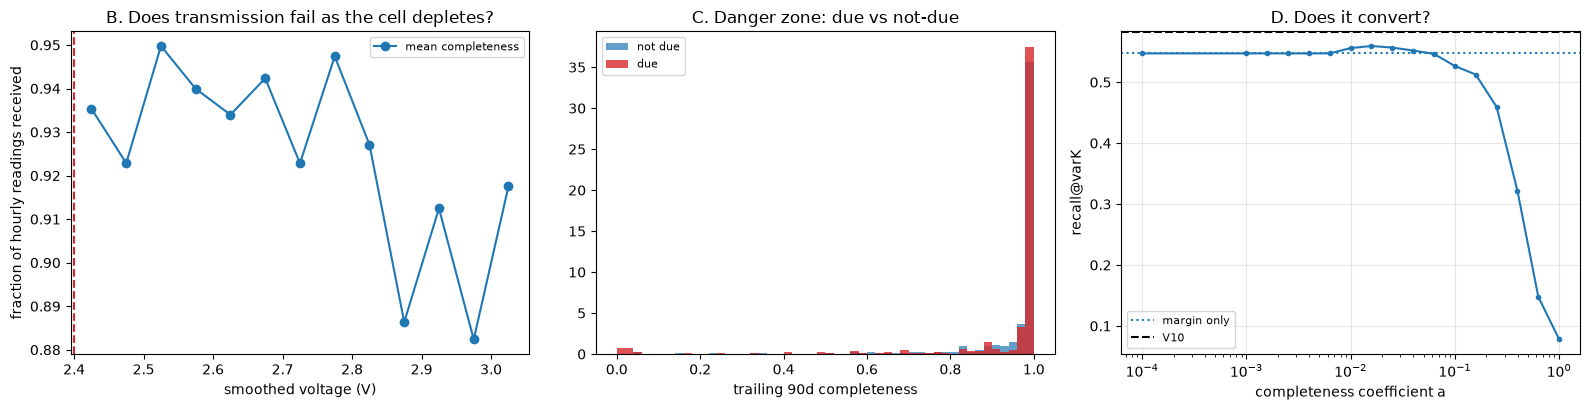

In [31]:
# Step 12: transmission completeness as an internal-resistance probe
# Expects: d (daily table), sm, Z2, Kmap, sc, devices, np, pd, plt
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ---------- A. per-device daily completeness on a REGULAR grid (missing day = 0) ----------
COMP = {}
for dev, g in d.groupby("device_id", observed=True):
    g = g.sort_values("date")
    day = pd.to_datetime(g.date).values.astype("datetime64[D]").astype(int)
    lo, hi = day.min(), day.max()
    arr = np.zeros(hi - lo + 1, dtype=np.int16)
    arr[day - lo] = g.n_obs.values
    COMP[dev] = (lo, arr)
print("devices with completeness grid:", len(COMP))

def comp_feats(dev, ci):
    lo, arr = COMP[dev]
    i = ci - lo
    if i <= 5 or i > len(arr): return {}
    out = {}
    for W, nm in [(30, "30"), (90, "90")]:
        w = arr[max(0, i - W):i]
        if len(w) < 5: continue
        out[f"comp_{nm}"]    = w.mean() / 24.0                 # graded: fraction of hours received
        out[f"zerodays_{nm}"] = (w == 0).mean()                # fully silent days
        out[f"partial_{nm}"]  = ((w > 0) & (w < 20)).mean()    # degraded but alive
    if i > 180:
        old = arr[max(0, i - 180):i - 90].mean() / 24.0
        new = arr[max(0, i - 90):i].mean() / 24.0
        out["comp_trend"] = new - old                          # is it getting worse?
    return out

rows = []
for (scen, cut), grp in Z2.groupby(["scenario", "cutoff"]):
    ci = np.datetime64(pd.Timestamp(cut), "D").astype(int)
    for dev in grp.device_id:
        r = {"scenario": scen, "device_id": dev}
        if dev in COMP: r.update(comp_feats(dev, ci))
        rows.append(r)
C = pd.DataFrame(rows)
Y = Z2.merge(C, on=["scenario", "device_id"], how="left")
for c in ["comp_30", "comp_90"]:
    Y[c + "_rel"] = Y[c] - Y.groupby("scenario")[c].transform("median")
print("merged:", Y.shape, "| comp_90 available:", Y.comp_90.notna().mean().round(3))
print(Y[["comp_30","comp_90","zerodays_90","partial_90","comp_trend"]]
      .describe(percentiles=[.1,.5,.9]).round(4).to_string())

# ---------- B. does completeness fall as the cell depletes? (the mechanism check) ----------
Y["vbin"] = pd.cut(Y.v_last, np.arange(2.40, 3.10, 0.05))
mech = Y.groupby("vbin", observed=True).agg(
    n=("comp_90","size"), comp90=("comp_90","mean"),
    zerod=("zerodays_90","mean"), partial=("partial_90","mean")).query("n > 200")
print("\n--- B. completeness vs voltage level (population) ---")
print(mech.round(4).to_string())

# ---------- C. within-scenario AUC, overall and inside margin strata ----------
def wsc(fr, col, min_due=3):
    g0 = fr.dropna(subset=[col])
    if g0.due.nunique() < 2 or g0[col].nunique() < 2: return np.nan
    s = 1 if roc_auc_score(g0.due, g0[col]) >= 0.5 else -1
    a = [roc_auc_score(g.due, s*g[col]) for _, g in g0.groupby("scenario")
         if g.due.sum() >= min_due and g.due.nunique() == 2 and g[col].nunique() >= 2]
    return np.mean(a) if a else np.nan

DZ = Y[Y.margin < 0.20].copy()
DZ["mstrat"] = pd.cut(DZ.margin, [0, .05, .10, .15, .20])
CF = ["comp_30","comp_90","comp_30_rel","comp_90_rel","zerodays_90","partial_90","comp_trend"]
print(f"\n--- C. within-scenario AUC, danger zone (n={len(DZ)}, due={int(DZ.due.sum())}) ---")
print(f"{'feature':16s} {'overall':>8s} " + " ".join(f"{str(b):>14s}" for b in DZ.mstrat.cat.categories))
print(f"{'margin (ref)':16s} {wsc(DZ,'margin'):8.3f}")
for c in CF:
    if c not in DZ or DZ[c].notna().sum() < 500: continue
    per = [wsc(g, c) for _, g in DZ.groupby("mstrat", observed=True)]
    print(f"{c:16s} {wsc(DZ,c):8.3f} " + " ".join(f"{v:14.3f}" if np.isfinite(v) else f"{'nan':>14s}" for v in per))

# ---------- D. does it convert? additive sweep + block stability ----------
Y["comp_c"] = Y.comp_90.fillna(Y.comp_90.median())
def score_c(fr, a): return -(fr.margin - a * (1.0 - fr.comp_c))    # less complete -> riskier
def rec_varK(fr, s, kmap=Kmap):
    fr = fr.assign(_s=s)
    return np.mean([g.nlargest(int(kmap.get(k,16)), "_s").due.sum()/max(g.due.sum(),1)
                    for k, g in fr.groupby("scenario")])

alphas = np.concatenate([[0], np.logspace(-3, 0, 16)])
curve = [rec_varK(Y, score_c(Y, a)) for a in alphas]
print("\n--- D. completeness coefficient sweep (recall@varK) ---")
for a, r in zip(alphas, curve):
    print(f"  a={a:.3e}  {r:.3f}" + (" <<<" if r == max(curve) else ""))
V10_REF = 0.582
print(f"  margin only {curve[0]:.3f} | best {max(curve):.3f} at a={alphas[int(np.argmax(curve))]:.3e}"
      f" | V10 {V10_REF:.3f}")

A_BEST = alphas[int(np.argmax(curve))]
blocks = np.array_split(sorted(Y.scenario.unique(), key=lambda s: int(s.split("_")[1])), 6)
print(f"\n--- chronological blocks at a={A_BEST:.3e} ---")
deltas = []
for i, blk in enumerate(blocks):
    g = Y[Y.scenario.isin(blk)]
    rm, rc = rec_varK(g, score_c(g, 0)), rec_varK(g, score_c(g, A_BEST))
    deltas.append(rc - rm)
    print(f"  block {i}  margin {rm:.3f}  +comp {rc:.3f}  delta {rc-rm:+.3f}")
print(f"  mean delta {np.mean(deltas):+.3f}   positive in {sum(x>0 for x in deltas)}/6 blocks")

# ---------- E. building confound ----------
b = Y.groupby("building").agg(comp=("comp_90","mean"), n=("comp_90","size")).query("n>200")
print(f"\n--- E. is completeness a building property? ---")
print(f"  building mean comp_90: min {b.comp.min():.3f}  max {b.comp.max():.3f}  sd {b.comp.std():.3f}")
print(f"  within-device sd of comp_90 across scenarios: "
      f"{Y.groupby('device_id')['comp_90'].std().median():.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
mids = [i.mid for i in mech.index]
ax[0].plot(mids, mech.comp90, marker="o", color="tab:blue", label="mean completeness")
ax[0].axvline(2.4, color="tab:red", ls="--"); ax[0].set_xlabel("smoothed voltage (V)")
ax[0].set_ylabel("fraction of hourly readings received"); ax[0].legend(fontsize=8)
ax[0].set_title("B. Does transmission fail as the cell depletes?")

s2 = DZ.dropna(subset=["comp_90"])
ax[1].hist(s2.loc[~s2.due,"comp_90"], bins=50, density=True, alpha=.7, label="not due")
ax[1].hist(s2.loc[ s2.due,"comp_90"], bins=50, density=True, alpha=.8, color="tab:red", label="due")
ax[1].set_xlabel("trailing 90d completeness"); ax[1].legend(fontsize=8)
ax[1].set_title("C. Danger zone: due vs not-due")

ax[2].semilogx(np.maximum(alphas,1e-4), curve, marker="o", ms=3)
ax[2].axhline(curve[0], ls=":", color="tab:blue", label="margin only")
ax[2].axhline(V10_REF, ls="--", color="k", label="V10")
ax[2].set_xlabel("completeness coefficient a"); ax[2].set_ylabel("recall@varK")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3); ax[2].set_title("D. Does it convert?")
plt.tight_layout(); plt.show()

--- A. crossing events ---
82 events spanning 509 days | mean gap 6.3d
events per calendar month:
end_time
1     12
2      4
3      9
4      3
5      9
6      3
7      7
8      1
9      8
10    13
11     6
12     7

--- B. clustering test ---
observed median within-building gap : 22 d
permutation null median             : 31 d [23, 40]
one-sided p (observed <= null)      : 0.0140
buildings with >=2 crossings: 14 of 24   max in one building: 15

--- C. within-scenario AUC, danger zone (n=3368, due=396) ---
feature           overall   (0.0, 0.05]   (0.05, 0.1]   (0.1, 0.15]   (0.15, 0.2]
margin              0.781         0.591         0.584         0.584         0.406
peer_low_excl       0.537         0.556         0.514         0.536         0.512
peer_low_frac       0.583         0.642         0.528         0.539         0.515
peer_med            0.484         0.630         0.523         0.521         0.570
vs_peer             0.593         0.637         0.541         0.512         0.5

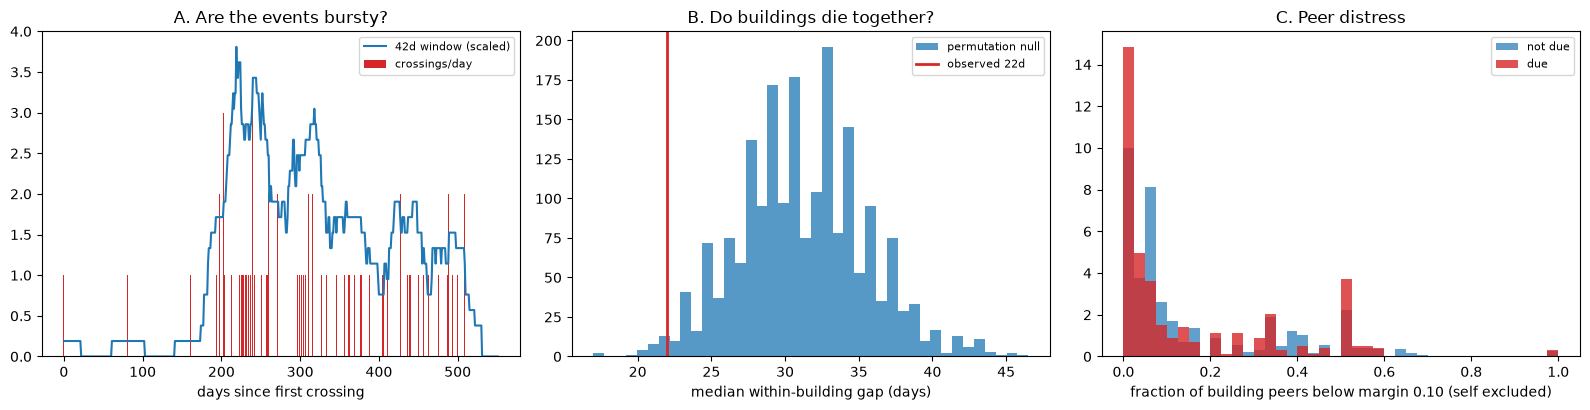

In [32]:
# Step 13: are crossings clustered, and do living peers carry the signal?
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
rng = np.random.default_rng(0)

cross = eol_s.dropna().sort_values()                      # 82 crossing events
bld   = devices.set_index("device_id")["building_id"]
room  = devices.set_index("device_id")["room_id"]

# ---------- A. does a burst structure reproduce the wiggle? ----------
days = (cross - cross.min()).dt.days.values
grid = np.arange(0, days.max() + 43)
hist = np.bincount(days, minlength=len(grid))[:len(grid)]
conv = np.convolve(hist, np.ones(42), mode="same")        # events inside a moving 42d window
print("--- A. crossing events ---")
print(f"82 events spanning {days.max()} days | mean gap {days.max()/81:.1f}d")
print("events per calendar month:")
print(cross.dt.month.value_counts().sort_index().to_string())

# ---------- B. are crossings clustered WITHIN buildings? (permutation test) ----------
def median_within_building_gap(dates, buildings):
    gaps = []
    for b, idx in pd.Series(range(len(dates))).groupby(buildings.values):
        dd = np.sort(dates[idx.values])
        if len(dd) >= 2: gaps.extend(np.diff(dd))
    return np.median(gaps) if gaps else np.nan

cb = bld.reindex(cross.index)
obs = median_within_building_gap(days, cb)
null = [median_within_building_gap(days, pd.Series(rng.permutation(cb.values), index=cb.index))
        for _ in range(2000)]
print(f"\n--- B. clustering test ---")
print(f"observed median within-building gap : {obs:.0f} d")
print(f"permutation null median             : {np.median(null):.0f} d "
      f"[{np.percentile(null,2.5):.0f}, {np.percentile(null,97.5):.0f}]")
print(f"one-sided p (observed <= null)      : {np.mean(np.array(null) <= obs):.4f}")
bc = cb.value_counts()
print(f"buildings with >=2 crossings: {(bc>=2).sum()} of {cb.nunique()}   "
      f"max in one building: {bc.max()}")

# ---------- C. DEPLOYABLE living-peer features ----------
Y2 = Y.copy()
g = Y2.groupby(["scenario", "building"])
Y2["peer_n"]        = g["margin"].transform("size")
Y2["peer_med"]      = g["margin"].transform("median")
Y2["peer_low_frac"] = g["margin"].transform(lambda s: (s < 0.10).mean())
Y2["peer_low_n"]    = g["margin"].transform(lambda s: (s < 0.10).sum())
Y2["vs_peer"]       = Y2.margin - Y2.peer_med
gr = Y2.groupby(["scenario", "room"])
Y2["room_low_frac"] = gr["margin"].transform(lambda s: (s < 0.10).mean())
Y2["room_med"]      = gr["margin"].transform("median")
Y2["vs_room"]       = Y2.margin - Y2.room_med
# exclude self so the feature is about the neighbours, not the battery itself
Y2["peer_low_excl"] = (Y2.peer_low_n - (Y2.margin < 0.10).astype(int)) / (Y2.peer_n - 1).clip(lower=1)

def wsc(fr, col, min_due=3):
    g0 = fr.dropna(subset=[col])
    if g0.due.nunique() < 2 or g0[col].nunique() < 2: return np.nan
    s = 1 if roc_auc_score(g0.due, g0[col]) >= 0.5 else -1
    return np.mean([roc_auc_score(x.due, s*x[col]) for _, x in g0.groupby("scenario")
                    if x.due.sum() >= min_due and x.due.nunique() == 2 and x[col].nunique() >= 2])

DZ2 = Y2[Y2.margin < 0.20].copy()
DZ2["mstrat"] = pd.cut(DZ2.margin, [0, .05, .10, .15, .20])
print(f"\n--- C. within-scenario AUC, danger zone (n={len(DZ2)}, due={int(DZ2.due.sum())}) ---")
print(f"{'feature':16s} {'overall':>8s} " + " ".join(f"{str(b):>13s}" for b in DZ2.mstrat.cat.categories))
for c in ["margin","peer_low_excl","peer_low_frac","peer_med","vs_peer",
          "room_low_frac","vs_room","peer_n"]:
    per = [wsc(x, c) for _, x in DZ2.groupby("mstrat", observed=True)]
    print(f"{c:16s} {wsc(DZ2,c):8.3f} " + " ".join(f"{v:13.3f}" if np.isfinite(v) else f"{'nan':>13s}" for v in per))

# ---------- D. does it convert? ----------
def rec_varK(fr, s, kmap=Kmap):
    fr = fr.assign(_s=s)
    return np.mean([x.nlargest(int(kmap.get(k,16)), "_s").due.sum()/max(x.due.sum(),1)
                    for k, x in fr.groupby("scenario")])
Y2["peer_c"] = Y2.peer_low_excl.fillna(0)
def score_p(fr, a): return -(fr.margin - a * fr.peer_c)
alphas = np.concatenate([[0], np.logspace(-3, -0.5, 18)])
curve = [rec_varK(Y2, score_p(Y2, a)) for a in alphas]
best = alphas[int(np.argmax(curve))]
print("\n--- D. peer-distress coefficient sweep ---")
for a, r in zip(alphas, curve): print(f"  a={a:.3e}  {r:.3f}" + (" <<<" if r == max(curve) else ""))
print(f"  margin {curve[0]:.3f} | best {max(curve):.3f} at a={best:.3e} | V10 0.582")

blocks = np.array_split(sorted(Y2.scenario.unique(), key=lambda s: int(s.split("_")[1])), 6)
dl = []
print(f"\n--- chronological blocks at a={best:.3e} ---")
for i, blk in enumerate(blocks):
    x = Y2[Y2.scenario.isin(blk)]
    rm, rp = rec_varK(x, score_p(x, 0)), rec_varK(x, score_p(x, best))
    dl.append(rp - rm); print(f"  block {i}  margin {rm:.3f}  +peer {rp:.3f}  delta {rp-rm:+.3f}")
print(f"  mean delta {np.mean(dl):+.3f}   positive in {sum(v>0 for v in dl)}/6 blocks")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].bar(grid, hist, width=1, color="tab:red", label="crossings/day")
ax[0].plot(grid, conv/42*8, color="tab:blue", lw=1.5, label="42d window (scaled)")
ax[0].set_xlabel("days since first crossing"); ax[0].legend(fontsize=8)
ax[0].set_title("A. Are the events bursty?")
ax[1].hist(null, bins=40, alpha=.75, label="permutation null")
ax[1].axvline(obs, color="tab:red", lw=2, label=f"observed {obs:.0f}d")
ax[1].set_xlabel("median within-building gap (days)"); ax[1].legend(fontsize=8)
ax[1].set_title("B. Do buildings die together?")
s3 = DZ2.dropna(subset=["peer_low_excl"])
ax[2].hist(s3.loc[~s3.due,"peer_low_excl"], bins=40, density=True, alpha=.7, label="not due")
ax[2].hist(s3.loc[ s3.due,"peer_low_excl"], bins=40, density=True, alpha=.8, color="tab:red", label="due")
ax[2].set_xlabel("fraction of building peers below margin 0.10 (self excluded)")
ax[2].legend(fontsize=8); ax[2].set_title("C. Peer distress")
plt.tight_layout(); plt.show()

In [33]:
#Step 14: the in-sample CEILING for any model on these features
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

FEATS_ALL = [c for c in ["margin","v_last","v_runmin","slope_7","slope_14","slope_30","slope_60",
    "slope_90","curv_30_90","dwell_c","dwell_45_f","days_below_50","days_below_55",
    "days_near_now","above_rmin","fresh_low","days_since_runmin","beta_wd_30","beta_wd_90",
    "beta_wd_trend","vrange_90","t_anom","t_now","comp_90","zerodays_90","peer_low_excl",
    "peer_med","vs_room","age_days","n_days_obs","E_dT"] if c in Y2.columns]
print(f"features available: {len(FEATS_ALL)}")

CAND = Y2[Y2.margin < 0.25].copy()
Xc = CAND[FEATS_ALL].astype(float)
med = Xc.median()

def ceiling(features, tag, model=None):
    m = model or HistGradientBoostingClassifier(max_depth=None, max_iter=800,
            learning_rate=0.1, min_samples_leaf=5, l2_regularization=0.0, random_state=0)
    m.fit(CAND[features].astype(float).fillna(med[features]), CAND.due)   # NO CV — memorise
    p = m.predict_proba(CAND[features].astype(float).fillna(med[features]))[:, 1]
    tmp = Y2.merge(CAND[["scenario","device_id"]].assign(p=p),
                   on=["scenario","device_id"], how="left")
    tmp["p"] = tmp.p.fillna(-1)
    r = rec_varK(tmp, tmp.p)
    print(f"  {tag:44s} {r:.3f}")
    return r

print(f"\n--- IN-SAMPLE CEILINGS (recall@varK; these are upper bounds, not results) ---")
print(f"  {'margin only (no fitting)':44s} {rec_varK(Y2, -Y2.margin):.3f}")
print(f"  {'V10 actual (out-of-fold)':44s} {0.582:.3f}")
print()
ceiling(["margin"],                              "GBM, margin alone")
ceiling(["margin","dwell_c"],                    "GBM, margin + dwell   <-- YOUR HYBRID")
ceiling(["margin","dwell_c","slope_60"],         "GBM, + slope")
ceiling(["margin","dwell_c","slope_60","beta_wd_90"], "GBM, + within-day IR")
ceiling(FEATS_ALL,                               f"GBM, ALL {len(FEATS_ALL)} features")

# explicit 2-D empirical cell table — the interpretable version of the hybrid
CAND["mb"] = pd.cut(CAND.margin, [0,.025,.05,.075,.10,.15,.20,.25])
CAND["db"] = pd.cut(CAND.dwell_c, [-1,14,43,90,180,400])
cell = CAND.groupby(["mb","db"], observed=True)["due"].agg(["mean","size"])
CAND["p_cell"] = CAND.set_index(["mb","db"]).index.map(cell["mean"])
tmp = Y2.merge(CAND[["scenario","device_id","p_cell"]], on=["scenario","device_id"], how="left")
tmp["p_cell"] = tmp.p_cell.fillna(-1)
print(f"\n  {'2-D empirical cell table (in-sample)':44s} {rec_varK(tmp, tmp.p_cell):.3f}")
print("\nthe risk surface the hybrid would exploit (due rate, n):")
print(cell.unstack().round(3).to_string())

# oracle: perfect ranking, the absolute ceiling
print(f"\n  {'ORACLE (perfect ranking)':44s} "
      f"{rec_varK(Y2, Y2.due.astype(float) + 1e-9*(-Y2.margin)):.3f}")

features available: 30

--- IN-SAMPLE CEILINGS (recall@varK; these are upper bounds, not results) ---
  margin only (no fitting)                     0.547
  V10 actual (out-of-fold)                     0.582

  GBM, margin alone                            0.622
  GBM, margin + dwell   <-- YOUR HYBRID        0.910
  GBM, + slope                                 0.968
  GBM, + within-day IR                         0.968
  GBM, ALL 30 features                         0.968

  2-D empirical cell table (in-sample)         0.568

the risk surface the hybrid would exploit (due rate, n):
                  mean                                            size                                       
db            (-1, 14] (14, 43] (43, 90] (90, 180] (180, 400] (-1, 14] (14, 43] (43, 90] (90, 180] (180, 400]
mb                                                                                                           
(0.0, 0.025]     0.692    0.688    0.395     0.262      0.026       13       32     

In [34]:
# Step 15: cost-weighted selection (urgency), bounded
C = Y2[Y2.margin < 0.25].copy()
C["eol_off"] = np.where(C.due, C.days_to_eff, np.nan)     # crossing day within window, due only

# 1. does margin predict WHEN a due battery crosses?
C["mb"] = pd.cut(C.margin, [0,.025,.05,.075,.10,.15,.20,.25])
u = C[C.due].groupby("mb", observed=True)["eol_off"].agg(["mean","median","size"])
print("--- crossing day within the 42d window, by margin (due only) ---")
print(u.round(1).to_string())
print(f"\ncorr(margin, crossing day | due) = {C[C.due].margin.corr(C[C.due].eol_off):.3f}")

# 2. urgency-weighted score.  E[offset|due] from margin only -> no per-row label leak
off_hat = C.groupby("mb", observed=True)["eol_off"].transform("mean")
p_hat   = C.groupby("mb", observed=True)["due"].transform("mean")
C["late_avoided"] = 10 * (48 - off_hat.fillna(21)).clip(lower=0)
C["S_p"]    = p_hat                                        # current: rank by probability
C["S_cost"] = p_hat * C.late_avoided - (1 - p_hat) * 62     # proposed: expected cost saving

for nm, col in [("rank by margin", "S_margin"), ("rank by P(due)", "S_p"),
                ("rank by expected COST saving", "S_cost")]:
    if col not in C: C[col] = -C.margin
    r = proxy_cost(C, col)
    print(f"{nm:32s} total {r['total']:7.1f}  early {r['early']:6.1f}  "
          f"late {r['late']:7.1f}  hits {r['hits']:.2f}  recall {r['recall']:.3f}")

# 3. ceiling: perfect knowledge of crossing day (bounds the whole idea)
C["S_oracle_urg"] = p_hat * 10 * (48 - C.eol_off.fillna(21)).clip(lower=0) - (1-p_hat)*62
r = proxy_cost(C, "S_oracle_urg")
print(f"{'ORACLE urgency (upper bound)':32s} total {r['total']:7.1f}  early {r['early']:6.1f}  "
      f"late {r['late']:7.1f}  hits {r['hits']:.2f}  recall {r['recall']:.3f}")

--- crossing day within the 42d window, by margin (due only) ---
               mean  median  size
mb                               
(0.0, 0.025]   11.7     7.0    65
(0.025, 0.05]  15.9    14.0    85
(0.05, 0.075]  23.9    23.0    73
(0.075, 0.1]   23.4    24.0    69
(0.1, 0.15]    25.8    28.0    64
(0.15, 0.2]    26.4    28.0    40
(0.2, 0.25]    25.6    27.0    19

corr(margin, crossing day | due) = 0.355
rank by margin                   total  2101.1  early  703.8  late  1397.4  hits 5.81  recall 0.588
rank by P(due)                   total  2131.1  early  699.4  late  1431.7  hits 5.74  recall 0.581
rank by expected COST saving     total  2125.2  early  700.0  late  1425.2  hits 5.76  recall 0.583
ORACLE urgency (upper bound)     total  2140.6  early  719.9  late  1420.7  hits 5.43  recall 0.549
